# SIBGRAPI 2026 — Beyond Watertight Geometry: Neural Unsigned Distance Fields

**Companion notebook for Block 2.** Everything here runs on **CPU** in a few minutes.

As in Block 1, the notebook is split into **LAB blocks**. The slide deck announces each LAB
on a *"Now to the notebook"* slide, and the LAB ends with a pointer back to the slide we
resume from. LAB D runs in its official repository (a *"Now to the repository"* slide).

| LAB | Topic | Comes from slides | Announced on | Back to slide |
|:--|:--|:--|:--|:--|
| **LAB 0** | Setup — run this first | — | — | — |
| **LAB A** | CAP-UDF: self-supervision through projection | 18–21 | 22 | 23 |
| **LAB B** | NeuralUDF: learn a UDF from photos, render it back | 42–46 | 47 | 48 |
| **LAB C** | DUDF: smooth the kink, keep the zero set | 56–60 | 61 | 62 |

Slide numbers refer to `block2.pdf`. `FAST_MODE = True` keeps every LAB short enough to
run live; set it to `False` for a longer training run.

---

# LAB 0 — Setup

> **Run this before the talk starts.** It only imports, seeds and pins the thread count.

Everything is CPU-only: `torch`, `numpy`, `matplotlib` and `scipy`.

In [1]:
import math
import time
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from scipy.spatial import cKDTree

SEED = 7
FAST_MODE = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
torch.set_num_threads(max(1, min(4, torch.get_num_threads())))

print("PyTorch:", torch.__version__)
print("Device:", device)
print("Threads:", torch.get_num_threads())

PyTorch: 2.14.0+cpu
Device: cpu
Threads: 4


---

# LAB A — CAP-UDF: self-supervision through projection

> **⟵ Coming from slides 18–21** &nbsp;·&nbsp; *"CAP-UDF: use the field to explain the point cloud" → "CAP-UDF also adapts extraction"*
> **Hand-off slide:** 22 — *"Now to the notebook"*

**Why we are here.** In Block 1 every query came with a **target distance**, computed from a
known surface. CAP-UDF drops those labels: the only input is a raw point cloud $P$. The
network is trained by moving queries with its own projection

$$\Pi_\theta(x)=x-f_\theta(x)\,\frac{\nabla_x f_\theta(x)}{\lVert\nabla_x f_\theta(x)\rVert_2+\varepsilon}$$

and asking the moved queries to coincide with the observed points:

$$\mathcal L_{\text{self}}=\operatorname{CD}\big(\Pi_\theta(Q),\,P\big).$$

We build a **deliberately simplified** version in 2D — one loss, one small MLP, no
progressive stage — so that the mechanism of slide 20 (*sample, project, compare*) is visible
step by step. The last section lists what the real method adds.

## A.1 The only input: a raw point cloud

We use the S-curve of slide 20, rescaled to $[-1,1]^2$. It is an **open** curve with two free
ends, exactly the kind of geometry that motivates UDFs. We observe only $N_P$ noisy samples of
it, in random order, with no normals and no distances.

The true curve is kept aside **for evaluation only**: training never sees it.

150 input points
farthest the true curve gets from any input point: 0.035


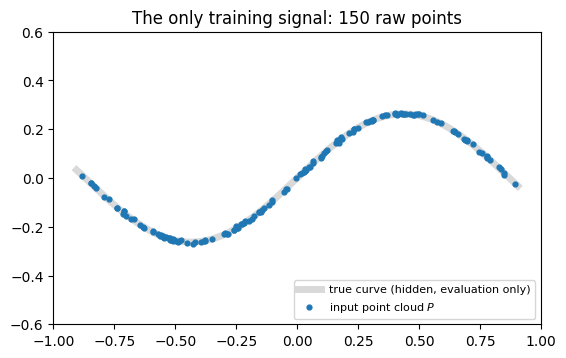

In [2]:
T_MAX = 0.905

def s_curve(t):
    # The S-curve y = 0.5 sin(1.9 x) of slide 20, scaled by 1 / 1.9.
    return torch.stack([t, 0.263 * torch.sin(3.61 * t)], dim=-1)

N_P = 150
P = s_curve((2 * torch.rand(N_P) - 1) * T_MAX) + 0.003 * torch.randn(N_P, 2)

# Hidden ground truth: used only to measure the result at the end.
curve_gt = s_curve(torch.linspace(-T_MAX, T_MAX, 4000))
gt_tree = cKDTree(curve_gt.numpy())

hole_P = cKDTree(P.numpy()).query(curve_gt.numpy())[0].max()
print(f"{N_P} input points")
print(f"farthest the true curve gets from any input point: {hole_P:.3f}")

plt.figure(figsize=(7.5, 3.8))
plt.plot(*curve_gt.T, color="0.85", lw=5, zorder=1, label="true curve (hidden, evaluation only)")
plt.scatter(*P.T, s=12, color="tab:blue", zorder=3, label="input point cloud $P$")
plt.gca().set_aspect("equal"); plt.xlim(-1, 1); plt.ylim(-0.6, 0.6)
plt.title("The only training signal: 150 raw points")
plt.legend(loc="lower right", fontsize=8)
plt.show()

## A.2 Query samples around the points

Queries are drawn from a Gaussian around every input point. The standard deviation is
**local**: the distance from the point to its $K$-th nearest neighbour, so that queries stay
close where the samples are dense and spread out where they are sparse (the same heuristic as
Neural-Pull and CAP-UDF). During training we also vary a global `scale`, so the network sees
both very near and farther queries.

local sigma: min 0.021 | mean 0.061 | max 0.194
one query batch: (600, 2)


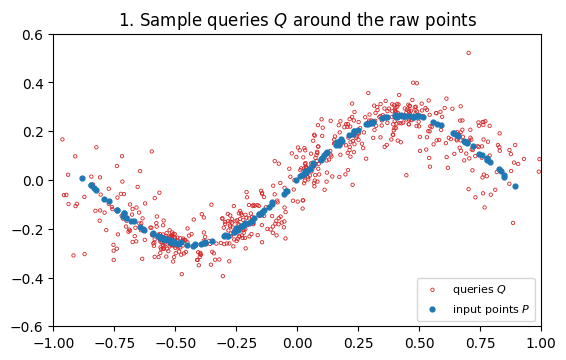

In [3]:
K = 8
knn_dist, _ = cKDTree(P.numpy()).query(P.numpy(), k=K + 1)   # k + 1: the nearest is the point itself
sigma = torch.from_numpy(knn_dist[:, -1]).float()              # [N_P] local noise scale

def sample_queries(per_point=4, scale=1.0):
    # Gaussian queries around every input point, with a per-point standard deviation.
    idx = torch.arange(len(P)).repeat_interleave(per_point)
    return P[idx] + scale * sigma[idx, None] * torch.randn(len(idx), 2)

Q = sample_queries(per_point=4)
print("local sigma: min {:.3f} | mean {:.3f} | max {:.3f}".format(
    sigma.min().item(), sigma.mean().item(), sigma.max().item()))
print("one query batch:", tuple(Q.shape))

plt.figure(figsize=(7.5, 3.8))
plt.scatter(*Q.T, s=6, facecolor="none", edgecolor="tab:red", lw=0.6, zorder=2, label="queries $Q$")
plt.scatter(*P.T, s=12, color="tab:blue", zorder=3, label="input points $P$")
plt.gca().set_aspect("equal"); plt.xlim(-1, 1); plt.ylim(-0.6, 0.6)
plt.title("1. Sample queries $Q$ around the raw points")
plt.legend(loc="lower right", fontsize=8)
plt.show()

## A.3 The network and the *differentiable* projection

The network is a small MLP. Two details matter here:

- **`Softplus` instead of ReLU.** The loss will be differentiated *through* $\nabla_x f_\theta$.
  A ReLU network has a piecewise-constant $\nabla_x f_\theta$; Softplus keeps it smooth.
- **`abs()` on the output**, so the field is unsigned by construction.

`project` is the Block 1 projection with one change. In Block 1 (slide *"Using
$\nabla_x f_\theta$ to project `xyz` onto $f_\theta=0$"*) we only *used* the result, so we
called `autograd.grad(..., create_graph=False)` and detached. Here the projected points
**are the loss**, so the gradient itself must stay in the graph: `create_graph=True`.

In [4]:
class UDFNet(nn.Module):
    def __init__(self, hidden=128, n_layers=4, beta=100.0):
        super().__init__()
        dims = [2] + [hidden] * n_layers
        self.layers = nn.ModuleList(nn.Linear(a, b) for a, b in zip(dims[:-1], dims[1:]))
        self.out = nn.Linear(hidden, 1)
        self.act = nn.Softplus(beta=beta)

    def forward(self, x):
        for layer in self.layers:
            x = self.act(layer(x))
        return self.out(x).abs()           # [B, 1], unsigned


def project(model, q, create_graph):
    # One projection step: q - f(q) * grad f(q) / |grad f(q)|.
    q = q.detach().requires_grad_(True)    # a fresh leaf: we differentiate with respect to q
    d = model(q)                           # [B, 1]  how far
    g = torch.autograd.grad(
        d, q,
        grad_outputs=torch.ones_like(d),
        create_graph=create_graph,         # True while training: the loss goes through g
    )[0]                                   # [B, 2]  which way
    g_hat = g / (g.norm(dim=-1, keepdim=True) + 1e-8)
    return q - d * g_hat


torch.manual_seed(SEED)
model = UDFNet()
print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))

UDFNet(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1-3): 3 x Linear(in_features=128, out_features=128, bias=True)
  )
  (out): Linear(in_features=128, out_features=1, bias=True)
  (act): Softplus(beta=100.0, threshold=20.0)
)
parameters: 50049


## A.4 The self-supervised loss: Chamfer distance to $P$

The symmetric Chamfer distance between two point sets has two terms:

$$\operatorname{CD}(A,B)=\frac1{|A|}\sum_{a\in A}\min_{b\in B}\lVert a-b\rVert
+\frac1{|B|}\sum_{b\in B}\min_{a\in A}\lVert a-b\rVert .$$

With $A=\Pi_\theta(Q)$ and $B=P$:

- the **first** term asks every projected query to land on *some* input point;
- the **second** asks every input point to be reached by *some* projected query, so the
  whole cloud is explained, not just the easy parts.

Before any training, the untrained network barely moves the queries: its output is small and
its gradient points in arbitrary directions. That is the *circular dependency* of slide 19: the
loss is only informative once the field already moves points sensibly. A.5 deals with it.

CD(P, P)              = 0.0000   (a perfect explanation)
CD(Q, P)              = 0.0607   (queries left where they are)
CD(Pi(Q), P) at init  = 0.0642


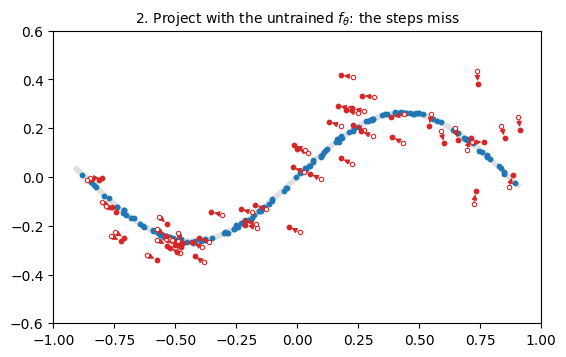

In [5]:
def chamfer(A, B):
    D = torch.cdist(A, B)                                  # [|A|, |B|] pairwise distances
    return D.min(dim=1).values.mean() + D.min(dim=0).values.mean()

Q_vis = sample_queries(per_point=1, scale=1.5)[::3]       # fixed queries, only for the figures
Q_vis_proj = project(model, Q_vis, create_graph=False).detach()

print(f"CD(P, P)              = {chamfer(P, P).item():.4f}   (a perfect explanation)")
print(f"CD(Q, P)              = {chamfer(Q, P).item():.4f}   (queries left where they are)")
print(f"CD(Pi(Q), P) at init  = {chamfer(project(model, Q, False).detach(), P).item():.4f}")

def draw_projection(ax, q, q_proj, title):
    ax.plot(*curve_gt.T, color="0.88", lw=4, zorder=1)
    ax.scatter(*P.T, s=10, color="tab:blue", zorder=3)
    for a, b in zip(q.numpy(), q_proj.numpy()):
        ax.annotate("", xy=b, xytext=a,
                    arrowprops=dict(arrowstyle="-|>", color="tab:red", lw=0.8, mutation_scale=8))
    ax.scatter(*q.T, s=10, facecolor="white", edgecolor="tab:red", lw=0.8, zorder=4)
    ax.scatter(*q_proj.T, s=10, color="tab:red", zorder=5)
    ax.set_aspect("equal"); ax.set_xlim(-1, 1); ax.set_ylim(-0.6, 0.6)
    ax.set_title(title, fontsize=10)

fig, ax = plt.subplots(figsize=(7.5, 3.8))
draw_projection(ax, Q_vis, Q_vis_proj, r"2. Project with the untrained $f_\theta$: the steps miss")
plt.show()

### Where does the loss reach the parameters?

$\Pi_\theta(q)=q-f_\theta(q)\,\hat g_\theta(q)$ depends on $\theta$ **twice**: through the step
length $f_\theta(q)$ and through the direction $\hat g_\theta(q)$. Without `create_graph=True`
the direction is a constant, and only the step length can be trained.

Building that "step length only" variant needs one more flag. `autograd.grad` frees the graph
it walks unless told otherwise, so with `create_graph=False` the graph of $d=f_\theta(q)$ would
be gone before the loss could use it. `retain_graph=True` keeps it — the same *what autograd
keeps* question as the Block 1 slides, now on the training side. We compare the gradient that
reaches the weights in both cases:

In [6]:
def project_step_only(model, q):
    # Same step, but grad f is a constant: only the step length f(q) is differentiable.
    q = q.detach().requires_grad_(True)
    d = model(q)
    g = torch.autograd.grad(d, q, grad_outputs=torch.ones_like(d),
                            retain_graph=True)[0]  # keep d's graph for the loss
    g_hat = g / (g.norm(dim=-1, keepdim=True) + 1e-8)
    return q - d * g_hat

def parameter_gradient(projection):
    model.zero_grad()
    chamfer(projection(model, Q), P).backward()
    return torch.cat([p.grad.flatten() for p in model.parameters()])

g_full = parameter_gradient(lambda m, q: project(m, q, create_graph=True))   # through f AND grad f
g_step = parameter_gradient(project_step_only)                               # through f only
model.zero_grad()

cos = torch.nn.functional.cosine_similarity(g_full, g_step, dim=0).item()
print(f"|dL/dtheta| through f and grad f: {g_full.norm():.4f}")
print(f"|dL/dtheta| through f only      : {g_step.norm():.4f}")
print(f"cosine between the two updates     : {cos:+.3f}")

|dL/dtheta| through f and grad f: 1.8097
|dL/dtheta| through f only      : 0.2768
cosine between the two updates     : +0.151


The two updates point in different directions: the direction term is a real part of the
training signal. Everything below uses `create_graph=True` — the second-order case of the
Block 1 slide on `create_graph`, with its extra memory cost.

## A.5 Breaking the circular dependency: a short warm-up

The Chamfer term scores each projected query against the input point nearest to **where it
landed**. That target moves with the projection, so a network that slides queries *along* the
curve pays as much as one that does not move them at all. Started from random weights, pure
Chamfer training can settle there: a field with a floor $f_\theta>0$ along part of the curve.

A fixed target removes that escape. For the first iterations we pull each query towards the
input point nearest to **the query itself** (the Neural-Pull loss):

$$\mathcal L_{\text{warm}}=\frac1{|Q|}\sum_{q\in Q}\big\lVert\Pi_\theta(q)-\operatorname{nn}_P(q)\big\rVert .$$

It is still self-supervised (the target is a raw point, not a distance), and once the field
moves points sensibly we switch to the Chamfer loss for the rest of training.

In [7]:
def neural_pull_loss(q_proj, q):
    nearest = torch.cdist(q, P).argmin(dim=1)             # fixed target: nearest point to q
    return (q_proj - P[nearest]).norm(dim=-1).mean()

## A.6 Training: sample, project, compare, backpropagate

One iteration is the loop of slide 20:

1. sample a fresh query batch $Q$ around $P$;
2. project it with the current network, keeping the graph;
3. compare with $P$: the warm-up loss first, then $\operatorname{CD}(\Pi_\theta(Q),P)$;
4. backpropagate to $\theta$ and update.

We log the Chamfer distance at every iteration (also during the warm-up) and record where the
fixed `Q_vis` queries land at a few iterations.

In [8]:
N_ITERS = 1500 if FAST_MODE else 3000
WARMUP_ITERS = 100
SNAPSHOTS = [0, 50, WARMUP_ITERS, N_ITERS]

torch.manual_seed(SEED)
np.random.seed(SEED)
model = UDFNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_ITERS)

snapshots, losses = {}, []
t0 = time.time()
for it in range(N_ITERS + 1):
    if it in SNAPSHOTS:
        snapshots[it] = project(model, Q_vis, create_graph=False).detach()
    if it == N_ITERS:
        break

    Q = sample_queries(per_point=4, scale=float(np.random.choice([0.5, 1.0, 2.0])))
    Q_proj = project(model, Q, create_graph=True)       # d AND grad f stay in the graph
    cd = chamfer(Q_proj, P)                             # the only supervision: the raw points
    loss = neural_pull_loss(Q_proj, Q) if it < WARMUP_ITERS else cd

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()
    losses.append(cd.item())

    if it % 250 == 0 or it == WARMUP_ITERS:
        stage = "warm-up" if it < WARMUP_ITERS else "chamfer"
        print(f"iter {it:5d} | {stage} | CD {cd.item():.4f}")

print(f"training: {time.time() - t0:.1f}s for {N_ITERS} iterations")

iter     0 | warm-up | CD 0.0475
iter   100 | chamfer | CD 0.0184
iter   250 | chamfer | CD 0.0121
iter   500 | chamfer | CD 0.0145
iter   750 | chamfer | CD 0.0122
iter  1000 | chamfer | CD 0.0127
iter  1250 | chamfer | CD 0.0113
training: 12.9s for 1500 iterations


## A.7 Watch the projection learn

Same queries, same one-step projection, at four moments of training: the start, the middle
and the end of the short warm-up, and the end of the Chamfer stage. At iteration 0 the steps
are tiny and random; by the end most arrows end on the cloud. This is the self-supervision
working: nobody told the network *any* distance.

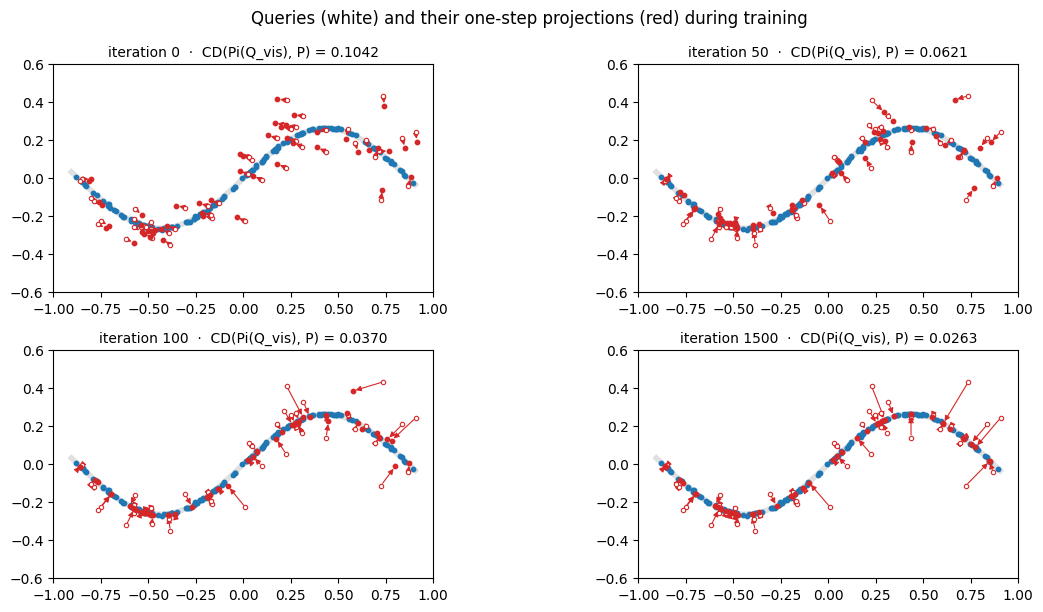

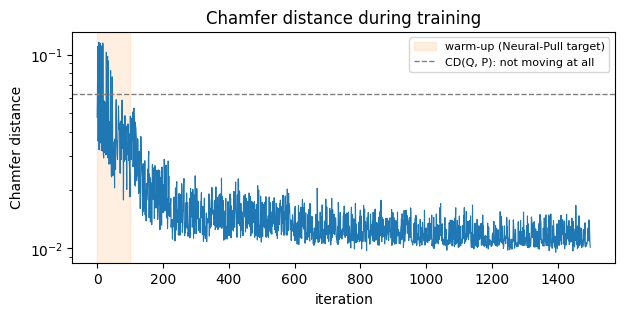

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.2))
for ax, (it, q_proj) in zip(axes.flat, snapshots.items()):
    cd = chamfer(q_proj, P).item()
    draw_projection(ax, Q_vis, q_proj, f"iteration {it}  ·  CD(Pi(Q_vis), P) = {cd:.4f}")
fig.suptitle("Queries (white) and their one-step projections (red) during training")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3))
plt.axvspan(0, WARMUP_ITERS, color="tab:orange", alpha=0.12, label="warm-up (Neural-Pull target)")
plt.semilogy(losses, lw=0.8)
plt.axhline(chamfer(sample_queries(per_point=4), P).item(), color="gray", ls="--", lw=1,
            label="CD(Q, P): not moving at all")
plt.xlabel("iteration"); plt.ylabel("Chamfer distance")
plt.title("Chamfer distance during training")
plt.legend(fontsize=8)
plt.show()

## A.8 The network learned a distance it was never shown

Now we use the hidden curve, for the first time, to compare $f_\theta$ with the **true** UDF
$u(x)=\min_{c\in\mathcal C}\lVert x-c\rVert$ on a grid.

mean f_theta on the input points: 0.0049   (ideal: 0)
mean |f_theta - u| where u < 0.05: 0.0043
mean |f_theta - u| where u < 0.1 : 0.0044
mean |f_theta - u| where u < 0.3 : 0.0052


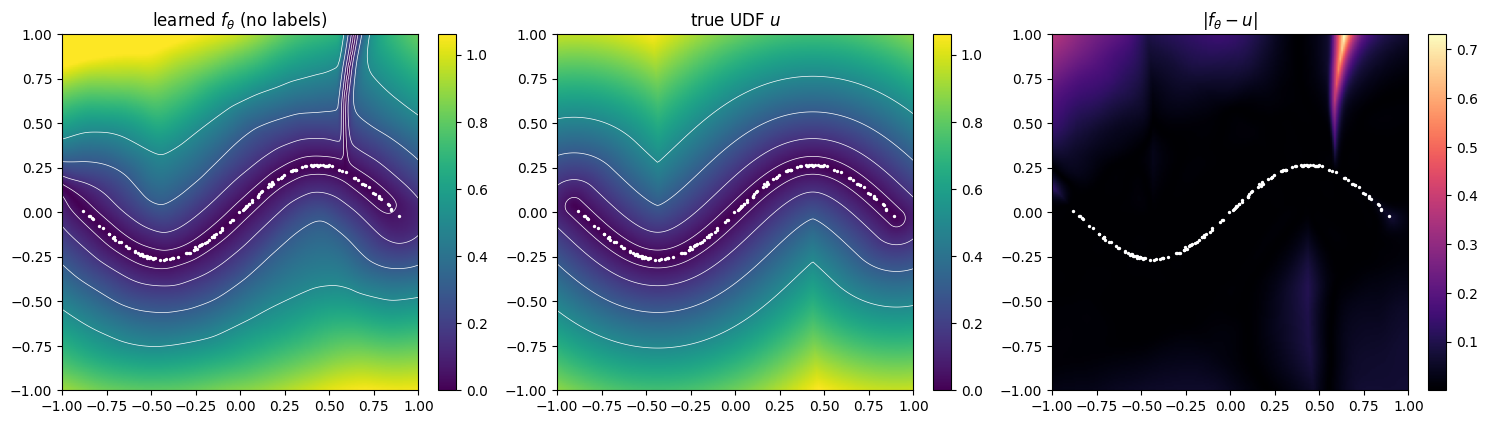

In [10]:
R = 200
lin = torch.linspace(-1, 1, R)
yy, xx = torch.meshgrid(lin, lin, indexing="ij")
grid = torch.stack([xx, yy], dim=-1).reshape(-1, 2)

with torch.inference_mode():
    f_grid = model(grid).squeeze(-1)
    f_on_P = model(P).squeeze(-1)
u_grid = torch.from_numpy(gt_tree.query(grid.numpy())[0]).float()
err = (f_grid - u_grid).abs()

print(f"mean f_theta on the input points: {f_on_P.mean():.4f}   (ideal: 0)")
for band in [0.05, 0.1, 0.3]:
    m = u_grid < band
    print(f"mean |f_theta - u| where u < {band:<4}: {err[m].mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
panels = [(f_grid, r"learned $f_\theta$ (no labels)", "viridis"),
          (u_grid, r"true UDF $u$", "viridis"),
          (err, r"$|f_\theta - u|$", "magma")]
vmax = u_grid.max().item()
for ax, (field, title, cmap) in zip(axes, panels):
    is_distance = cmap == "viridis"
    kw = dict(vmin=0, vmax=vmax) if is_distance else {}
    im = ax.imshow(field.reshape(R, R), extent=[-1, 1, -1, 1], origin="lower", cmap=cmap, **kw)
    if is_distance:   # the same iso-lines on both distance maps
        ax.contour(lin, lin, field.reshape(R, R), levels=[0.05, 0.15, 0.3, 0.5],
                   colors="white", linewidths=0.5)
    ax.scatter(*P.T, s=2, color="white")
    ax.set_title(title); ax.set_aspect("equal")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

Close to the curve the learned field matches the true UDF, without ever seeing it. Look,
however, for **thin valleys that leave the curve and run to the border** of the box. They are
not a bug of this notebook. `abs()` makes the field $|h_\theta|$ for a raw output $h_\theta$, and
$|h_\theta|$ is zero exactly where $h_\theta$ changes sign. A sign-change line cannot simply stop
at the end of an **open** curve: it has to continue somewhere, and it does so where there is no
data to object. This is the missing-sign problem of UDFs again, and the reason extraction
methods such as MeshUDF (Lab D) have to reason about pseudo-signs.

## A.9 Diagnose: are the gradients as good as the distances?

The Lab A slide asks us to look for queries that **overshoot or collapse**. A good distance
value is not enough: the projection also needs the right *direction*. We project fresh queries
with **one** step and measure how far each lands from the true curve.

one-step landing error: median 0.0015 | 95% 0.0045
queries landing more than 0.02 from the curve: 2.2%
|grad f|: median 0.998 (ideal 1) | 5% 0.914 | 95% 1.078


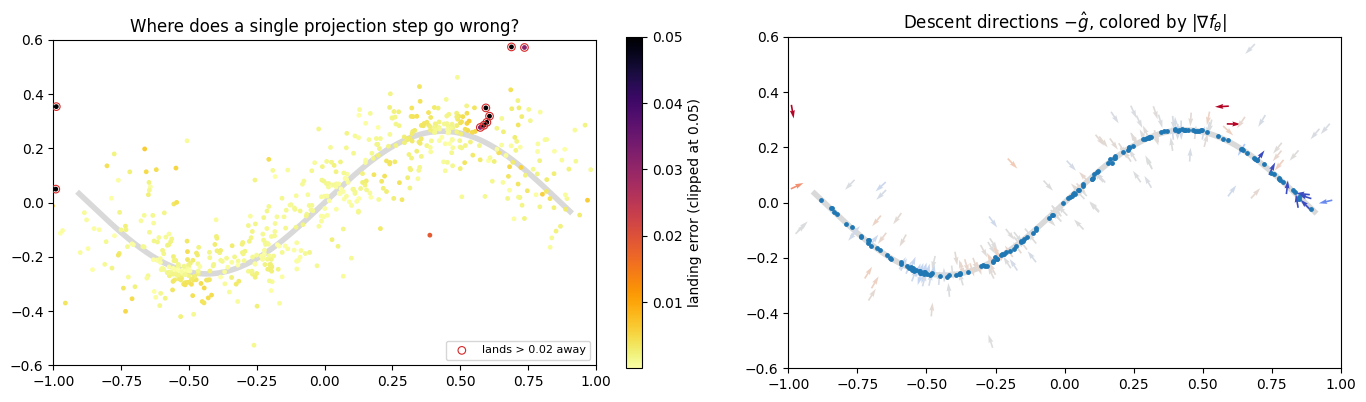

In [11]:
Q_test = sample_queries(per_point=4, scale=1.5)
Q_test_proj = project(model, Q_test, create_graph=False).detach()
landing = torch.from_numpy(gt_tree.query(Q_test_proj.numpy())[0]).float()

q = Q_test.detach().requires_grad_(True)
d = model(q)
g = torch.autograd.grad(d, q, grad_outputs=torch.ones_like(d))[0]
grad_norm = g.norm(dim=-1)

bad = landing > 0.02
print(f"one-step landing error: median {landing.median():.4f} | 95% {landing.quantile(0.95):.4f}")
print(f"queries landing more than 0.02 from the curve: {bad.float().mean():.1%}")
print(f"|grad f|: median {grad_norm.median():.3f} (ideal 1) | "
      f"5% {grad_norm.quantile(0.05):.3f} | 95% {grad_norm.quantile(0.95):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(*curve_gt.T, color="0.85", lw=4, zorder=1)
sc = axes[0].scatter(*Q_test.T, c=landing.clamp(max=0.05), s=6, cmap="inferno_r", zorder=2)
axes[0].scatter(*Q_test[bad].T, s=30, facecolor="none", edgecolor="tab:red", lw=0.8,
                zorder=3, label="lands > 0.02 away")
fig.colorbar(sc, ax=axes[0], fraction=0.046, label="landing error (clipped at 0.05)")
axes[0].set_title("Where does a single projection step go wrong?")
axes[0].legend(loc="lower right", fontsize=8)

sub = slice(None, None, 4)
gh = (g / (grad_norm[:, None] + 1e-8)).detach()
axes[1].plot(*curve_gt.T, color="0.85", lw=4, zorder=1)
axes[1].quiver(*Q_test[sub].T, *(-gh[sub]).T, grad_norm[sub].detach(), cmap="coolwarm",
               clim=(0.5, 1.5), scale=40, width=0.003, zorder=2)
axes[1].scatter(*P.T, s=6, color="tab:blue", zorder=3)
axes[1].set_title(r"Descent directions $-\hat g$, colored by $|\nabla f_\theta|$")
for ax in axes:
    ax.set_aspect("equal"); ax.set_xlim(-1, 1); ax.set_ylim(-0.6, 0.6)
plt.tight_layout()
plt.show()

The failures are not random (their exact positions depend on the seed). In this run:

- they cluster where the **spurious valley** of A.8 leaves the curve: those queries follow the
  valley instead of the curve;
- a few sit **beyond the open ends**, near the border, where almost no training queries were drawn;
- near the right end, $\lVert\nabla f_\theta\rVert$ drops well below $1$ (dark blue arrows): the
  valley is shallow there, so the field is no longer a distance.

Elsewhere, distances and directions are both good. The point of the Lab A slide: the distance
map of A.8 looks fine in all these places — only the gradient reveals the problem.

## A.10 Densify: project many queries onto the learned zero set

Once trained, the field is used exactly as in Block 1: many queries and a few projection steps
with `create_graph=False` (inference only). We then drop the points that end far from every
input point: they followed one of the spurious valleys of A.8. The result is a **denser**
cloud than the input, filling the holes between the raw samples.

dense points kept: 4484 (99.6% of the projected queries)
mean distance to the true curve:  input 0.0025  ->  densified 0.0016
curve covered within 0.01:  input 72%  ->  densified 93%


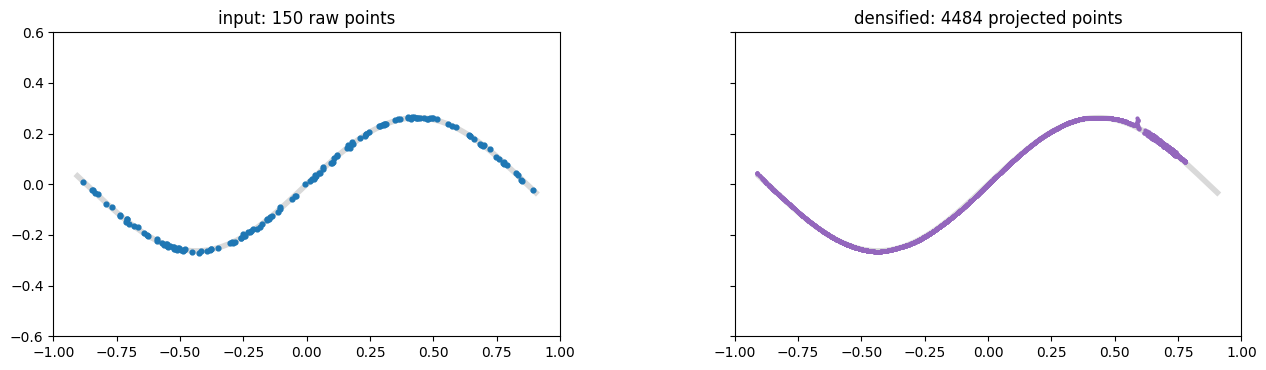

In [12]:
def densify(model, n_per_point=30, steps=5, max_gap=0.05):
    x = sample_queries(per_point=n_per_point, scale=1.5)
    for _ in range(steps):
        x = project(model, x, create_graph=False).detach()   # Block 1 loop: no graph kept
    # Drop points that ran into a spurious valley, far from every observed point.
    keep = torch.from_numpy(cKDTree(P.numpy()).query(x.numpy())[0] < max_gap)
    return x[keep], keep.float().mean().item()

def coverage(pts, radius=0.01):
    # Fraction of the true curve that has a point within `radius`.
    return (cKDTree(pts.numpy()).query(curve_gt.numpy())[0] < radius).mean()

dense, kept = densify(model)
dist_dense = gt_tree.query(dense.numpy())[0]
dist_input = gt_tree.query(P.numpy())[0]

print(f"dense points kept: {len(dense)} ({kept:.1%} of the projected queries)")
print(f"mean distance to the true curve:  input {dist_input.mean():.4f}  ->  densified {dist_dense.mean():.4f}")
print(f"curve covered within 0.01:  input {coverage(P):.0%}  ->  densified {coverage(dense):.0%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), sharey=True)
for ax, pts, title in [(axes[0], P, f"input: {len(P)} raw points"),
                       (axes[1], dense, f"densified: {len(dense)} projected points")]:
    ax.plot(*curve_gt.T, color="0.85", lw=4, zorder=1)
    ax.scatter(*pts.T, s=4 if len(pts) > 500 else 12, zorder=2,
               color="tab:blue" if len(pts) < 500 else "tab:purple")
    ax.set_aspect("equal"); ax.set_xlim(-1, 1); ax.set_ylim(-0.6, 0.6)
    ax.set_title(title)
plt.tight_layout()
plt.show()

In the interior of the curve the holes between samples are filled, and the new points lie
closer to the true curve than the noisy input does. Look at the **open ends**, though: the
dense cloud stops short of the last input points. Near an end the valley of $f_\theta$ is
shallow (A.9), so the projected points slide along it towards the deeper part instead of
staying at the tip. Open boundaries are exactly where unsigned fields are hardest.

## A.11 What this simplified version leaves out

We kept only the mechanism. The actual CAP-UDF (Zhou et al., NeurIPS 2022) adds, among other
things:

- **consistency-aware details** of the objective, beyond one plain Chamfer term;
- a **progressive surface approximation** stage: once the field is reasonable, low-distance
  projected points are added to the target set, and training continues on the densified cloud;
- **3D** shapes and scenes, larger networks and much longer schedules;
- a **gradient-based Marching Cubes** adaptation for extracting a mesh from the UDF.

Check the paper and the official repository (`junshengzhou/CAP-UDF`) before quoting details.

### Things to try

1. **No direction training.** Replace `project(model, Q, create_graph=True)` in the loop with
   `project_step_only(model, Q)` from A.4. Only the step length is learned: how do the
   snapshots and the landing errors change?
2. **No warm-up.** Set `WARMUP_ITERS = 0` and try a few values of `SEED`. Some runs stall with a
   distance floor along part of the curve: the circular dependency of slide 19, live.
3. **Fewer points.** Set `N_P = 40`: when does the densified cloud stop filling the holes?
4. **Uniform queries.** Add queries drawn uniformly in $[-1,1]^2$. Far queries dominate the loss;
   watch what happens to the field near the curve.
5. **More noise.** Raise the `0.003` noise in A.1 and look at the thickness of the zero set.

> **↪ Back to the slides — slide 23:** *"The hidden variable is gradient quality"*

---

---

# LAB B — NeuralUDF: learn a UDF from photos, render it back

> **⟵ Coming from slides 42–46** &nbsp;·&nbsp; *"NeuralUDF: learn a UDF by rendering it back into the photos" → "After training: render new views, extract the surface"*
> **Hand-off slide:** 47 — *"Now to the notebook"*

**Why we are here.** LAB A still had 3D evidence: a point cloud. Here the only input is a set
of **photos** and their camera poses. The UDF is learned *through a renderer*: render every
photo from the current field, compare it with the real photo, backpropagate (slide 42).

We work in 2D so that everything stays visible. The scene is two coloured open curves, each
camera is a pinhole with a 60° field of view, and its "photo" is a **row of 96 pixels**. The
renderer is NeuralUDF's (slides 43–44):

$$\sigma(t)=\Psi(t)\,\Omega_\kappa(f)+\big(1-\Psi(t)\big)\,\Omega_\kappa(-f),\qquad
\hat C(\mathbf r)=\sum_i w_i\,\mathbf c_i+\Big(1-\sum_i w_i\Big)\,\mathbf c_{\text{bg}}.$$

As in LAB A this is a **deliberately simplified** version: one small MLP for the distance, one
for the colour, no hierarchical sampling. B.8 lists what the paper adds.

## B.1 The scene, and the only training data: 24 photos

An open arc and a bar, with colours that change along them. Both curves have free ends, and
from some cameras one hides part of the other: the two situations a UDF renderer must handle.

The curves are kept **for evaluation only**. Training sees the photos and the camera rays,
nothing else.

In [3]:
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap

def colour_ramp(stops, n):
    return LinearSegmentedColormap.from_list("ramp", stops)(np.linspace(0, 1, n))[:, :3]

# Hidden scene: an open arc and a bar, each coloured along its length.
th = np.radians(np.linspace(40, 320, 400))
arc = np.column_stack([-0.15 + 0.65 * np.cos(th), 0.65 * np.sin(th)])
s = np.linspace(0, 1, 160)[:, None]
bar = (1 - s) * np.array([0.78, -0.60]) + s * np.array([0.98, 0.45])
scene = [(arc, colour_ramp(["#297791", "#EDB840", "#483579"], len(arc) - 1)),
         (bar, colour_ramp(["#BF5C38", "#EDB840"], len(bar) - 1))]
seg_a = np.concatenate([c[:-1] for c, _ in scene])      # segment start points
seg_b = np.concatenate([c[1:] for c, _ in scene])       # segment end points
seg_rgb = np.concatenate([rgb for _, rgb in scene])     # segment colours
BACKGROUND = np.ones(3)                                 # white

def true_udf(p):
    # Exact distance to the curves. Evaluation only: training never calls it.
    e = seg_b - seg_a
    u = np.clip(((p[:, None] - seg_a) * e).sum(-1) / (e * e).sum(-1), 0, 1)
    return np.linalg.norm(p[:, None] - (seg_a + u[..., None] * e), axis=-1).min(1)

# Cameras on a circle, looking at the centre. Every pixel is one ray: an origin and a direction.
N_CAMS, CAM_R, FOV, W = 24, 2.4, np.radians(60), 96

def camera(k):
    phi = 2 * np.pi * k / N_CAMS + 0.1
    o = CAM_R * np.array([np.cos(phi), np.sin(phi)])
    look = -o / np.linalg.norm(o)
    a = ((np.arange(W) + 0.5) / W - 0.5) * FOV          # angle of each pixel
    d = np.column_stack([np.cos(a) * look[0] - np.sin(a) * look[1],
                         np.sin(a) * look[0] + np.cos(a) * look[1]])
    return np.repeat(o[None], W, 0), d

def cross2(a, b):
    return a[..., 0] * b[..., 1] - a[..., 1] * b[..., 0]

def take_photo(o, d):
    # The colour of the first curve each ray hits, or the background.
    e = seg_b - seg_a
    w = seg_a[None] - o[:, None]
    den = cross2(d[:, None], e[None])
    with np.errstate(divide="ignore", invalid="ignore"):
        t = cross2(w, e[None]) / den
        u = cross2(w, d[:, None]) / den
    t = np.where((np.abs(den) > 1e-12) & (t > 1e-4) & (u >= 0) & (u <= 1), t, np.inf)
    k = t.argmin(1)
    hit = np.isfinite(t[np.arange(len(t)), k])
    return np.where(hit[:, None], seg_rgb[k], BACKGROUND)

cams = [camera(k) for k in range(N_CAMS)]
photos = np.stack([take_photo(*c) for c in cams])       # (24, 96, 3): the training data
rays_o = torch.tensor(np.concatenate([c[0] for c in cams]), dtype=torch.float32)
rays_d = torch.tensor(np.concatenate([c[1] for c in cams]), dtype=torch.float32)
pixels = torch.tensor(photos.reshape(-1, 3), dtype=torch.float32)
print(f"{N_CAMS} cameras x {W} pixels = {len(pixels)} training rays")

24 cameras x 96 pixels = 2304 training rays


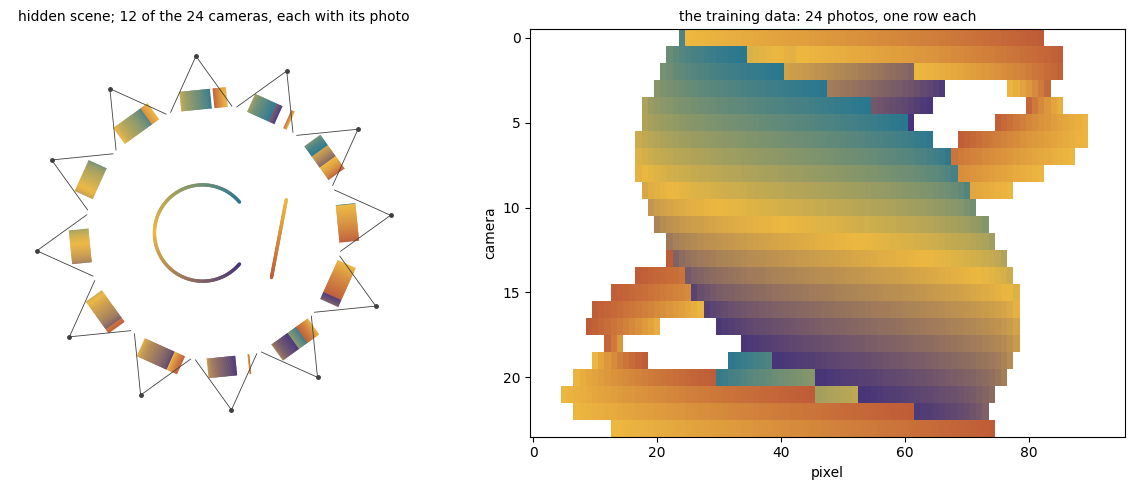

In [4]:
def draw_rig(ax, images, every=2, dist=0.72, thick=0.26):
    # Each camera: its centre, its frustum and its image, drawn on the image plane.
    for k in range(0, N_CAMS, every):
        o = cams[k][0][0]
        look = -o / np.linalg.norm(o)
        side = np.array([-look[1], look[0]])
        half, c0 = dist * np.tan(FOV / 2), o + dist * look
        for sgn in (-1, 1):
            ax.plot(*np.stack([o, c0 + sgn * half * side]).T, color="0.25", lw=0.6)
        edges = np.linspace(-half, half, W + 1)
        quads = [[c0 + a * side, c0 + b * side, c0 + b * side - thick * look, c0 + a * side - thick * look]
                 for a, b in zip(edges[:-1], edges[1:])]
        ax.add_collection(PolyCollection(quads, facecolors=images[k], edgecolors=images[k], linewidths=0.3))
        ax.plot(*o, "o", ms=2.5, color="0.25")
    ax.set_aspect("equal"); ax.set_xlim(-2.75, 2.75); ax.set_ylim(-2.75, 2.75); ax.axis("off")

def draw_scene(ax, **kw):
    for pts, rgb in scene:
        for a, b, c in zip(pts[:-1:2], pts[1::2], rgb[::2]):
            ax.plot(*np.stack([a, b]).T, color=c, lw=kw.get("lw", 2.5), solid_capstyle="round")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw=dict(width_ratios=[1, 1.15]))
draw_scene(axes[0]); draw_rig(axes[0], photos)
axes[0].set_title("hidden scene; 12 of the 24 cameras, each with its photo", fontsize=10)
axes[1].imshow(photos, aspect="auto", interpolation="nearest")
axes[1].set_xlabel("pixel"); axes[1].set_ylabel("camera")
axes[1].set_title("the training data: 24 photos, one row each", fontsize=10)
plt.tight_layout()
plt.show()

## B.2 The field: a distance network and a colour network

$f_\theta(\mathbf x)$ is a small MLP with Fourier features; its output goes through $|\cdot|$, so
it is never negative and can touch zero with a V-shaped kink. $\mathbf c_\theta(\mathbf x)$ gives
a colour at every point (view-independent here). Training starts from the UDF of a **circle**,
the 2D version of the sphere initialisation used by NeuS and NeuralUDF: step 0 on slide 45.

In [5]:
class Fourier(nn.Module):
    def __init__(self, n_freq):
        super().__init__()
        self.register_buffer("freq", 2.0 ** torch.arange(n_freq) * math.pi)

    def forward(self, x):
        xf = x[..., None] * self.freq
        return torch.cat([x, xf.sin().flatten(-2), xf.cos().flatten(-2)], -1)

class UDFScene(nn.Module):
    def __init__(self, hidden=96):
        super().__init__()
        self.enc_f, self.enc_c = Fourier(3), Fourier(6)
        act = lambda: nn.Softplus(beta=100)
        self.f_net = nn.Sequential(nn.Linear(14, hidden), act(), nn.Linear(hidden, hidden), act(),
                                   nn.Linear(hidden, hidden), act(), nn.Linear(hidden, 1))
        self.c_net = nn.Sequential(nn.Linear(26, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(),
                                   nn.Linear(64, 3))

    def udf(self, x):
        return self.f_net(self.enc_f(x)).squeeze(-1).abs()

    def color(self, x):
        return torch.sigmoid(self.c_net(self.enc_c(x)))

LIM, INIT_R = 1.45, 0.8     # the field lives in [-LIM, LIM]^2; start from a circle of radius INIT_R

def init_circle(model, steps=300):
    opt = torch.optim.Adam(model.f_net.parameters(), lr=1e-3)
    for _ in range(steps):
        x = (2 * torch.rand(2048, 2) - 1) * LIM
        loss = (model.udf(x) - (x.norm(dim=-1) - INIT_R).abs()).abs().mean()
        opt.zero_grad(); loss.backward(); opt.step()

grid = np.linspace(-LIM, LIM, 160)
grid_pts = np.stack(np.meshgrid(grid, grid), -1).reshape(-1, 2)

@torch.no_grad()
def field_image(model):
    return model.udf(torch.tensor(grid_pts, dtype=torch.float32)).numpy().reshape(len(grid), len(grid))

## B.3 The renderer: from distances to a pixel

For every pixel (slide 43):

1. walk along its ray and query $f$ and $\mathbf c$ at each sample;
2. turn distances into **weights**: the NeuS density $\Omega_\kappa(f)=\kappa\,|\cos\theta|\,(1-\Phi_\kappa(f))$,
   with the sign of $f$ flipped by the visibility indicator $\Psi$ once the ray has passed a
   surface (slide 44);
3. the pixel is the weighted colour, plus the background for whatever weight is left.

$\Psi$ is built from two quantities: $h=1-\exp(-\alpha\,\phi_\beta(f)\,\delta)$, *"a surface is
here"*, and $m=[\langle\mathbf v,\nabla f\rangle\ge 0]$, *"the ray is already moving away from
it"*: $\;\Psi_i=\prod_{j<i}(1-h_j m_j)$.

One simplification: along a ray, $\langle\mathbf v,\nabla f\rangle = df/dt$. We read $|\cos\theta|$
and $m$ off the distances of consecutive samples instead of differentiating the network at
every sample, which keeps the lab fast on CPU.

In [6]:
NEAR, FAR, N_SAMPLES = 1.2, 3.6, 128     # ray segment that covers the scene, samples per ray
ALPHA = 20.0                              # constant in the surface probability h (paper: 20)
BG = torch.tensor(BACKGROUND, dtype=torch.float32)

def render(udf, color, o, d, kappa, beta, use_indicator=True, jitter=False):
    R = len(o)
    dt = (FAR - NEAR) / (N_SAMPLES - 1)
    t = torch.linspace(NEAR, FAR, N_SAMPLES).expand(R, N_SAMPLES)
    if jitter:
        t = t + (torch.rand(R, 1) - 0.5) * dt              # one random shift per ray
    x = o[:, None] + t[..., None] * d[:, None]             # (R, N, 2) samples on each ray
    f = udf(x)                                             # step 1: distance at every sample

    # <v, grad f> = df/dt along the ray: positive once the ray moves away from a surface.
    cos = (torch.diff(f, dim=1, append=2 * f[:, -1:] - f[:, -2:-1]) / dt).clamp(-1, 1)

    # Visibility indicator: Psi drops to 0 once the ray has passed a surface.
    if use_indicator:
        e = torch.exp(-beta * f)
        h = 1 - torch.exp(-ALPHA * beta * e / (1 + e) ** 2 * dt)             # a surface is here
        m = (torch.cat([cos[:, 1:], cos[:, -1:]], 1) >= 0).float().detach()   # already passed it
        psi = torch.cumprod(torch.cat([torch.ones(R, 1), 1 - h[:, :-1] * m[:, :-1]], 1), 1)
    else:
        psi = torch.ones_like(f)

    # Step 2: density from the (flipped) distance, then volume-rendering weights.
    omega = lambda s: kappa * cos.abs() * (1 - torch.sigmoid(kappa * s))
    sigma = psi * omega(f) + (1 - psi) * omega(-f)
    alpha = 1 - torch.exp(-sigma * dt)
    T = torch.cumprod(torch.cat([torch.ones(R, 1), 1 - alpha[:, :-1] + 1e-7], 1), 1)
    w = T * alpha

    # Step 3: weighted colour, plus the background for the weight that is left.
    pixel = (w[..., None] * color(x)).sum(1) + (1 - w.sum(1, keepdim=True)) * BG
    return dict(pixel=pixel, w=w, t=t, f=f, psi=psi)

@torch.no_grad()
def render_all(udf, color, kappa, beta, use_indicator=True, o=None, d=None):
    o = rays_o if o is None else o
    d = rays_d if d is None else d
    out = render(udf, color, o, d, kappa, beta, use_indicator)
    return out["pixel"].clamp(0, 1).numpy().reshape(-1, W, 3)

### Is the renderer right? Feed it the true UDF

Before learning anything, render the photos from the **true** distance and colours. With the
visibility indicator they should match the real photos. Without it ($\Psi\equiv 1$) every
surface lets light through, and pixels mix the front and the back sheet (slide 44).

true UDF, with the indicator:    |render - photo| = 0.025
true UDF, without the indicator: |render - photo| = 0.092


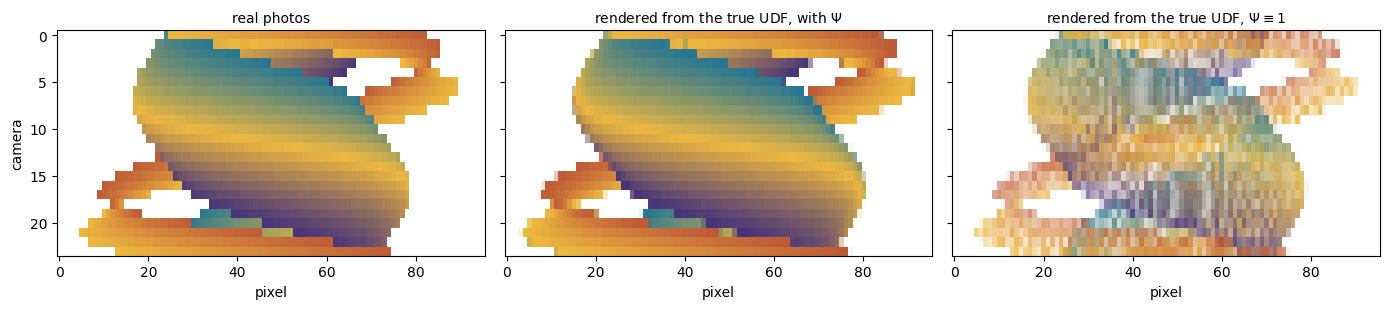

In [7]:
truth_pts = 0.5 * (seg_a + seg_b)
truth_tree = cKDTree(truth_pts)

def true_f(x):
    return torch.tensor(truth_tree.query(x.reshape(-1, 2).numpy())[0].reshape(x.shape[:-1]), dtype=torch.float32)

def true_c(x):
    idx = truth_tree.query(x.reshape(-1, 2).numpy())[1]
    return torch.tensor(seg_rgb[idx].reshape(*x.shape[:-1], 3), dtype=torch.float32)

SHARP = 300.0                      # the sharpness training ends with
with_psi = render_all(true_f, true_c, SHARP, SHARP, use_indicator=True)
without_psi = render_all(true_f, true_c, SHARP, SHARP, use_indicator=False)
print(f"true UDF, with the indicator:    |render - photo| = {np.abs(with_psi - photos).mean():.3f}")
print(f"true UDF, without the indicator: |render - photo| = {np.abs(without_psi - photos).mean():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.2), sharey=True)
for ax, img, title in [(axes[0], photos, "real photos"),
                       (axes[1], with_psi, "rendered from the true UDF, with $\\Psi$"),
                       (axes[2], without_psi, "rendered from the true UDF, $\\Psi\\equiv 1$")]:
    ax.imshow(img, aspect="auto", interpolation="nearest")
    ax.set_title(title, fontsize=10); ax.set_xlabel("pixel")
axes[0].set_ylabel("camera")
plt.tight_layout()
plt.show()

Now the starting point of training: the circle, and a colour network that has learned nothing
yet. Its renders are grey and in the wrong places.

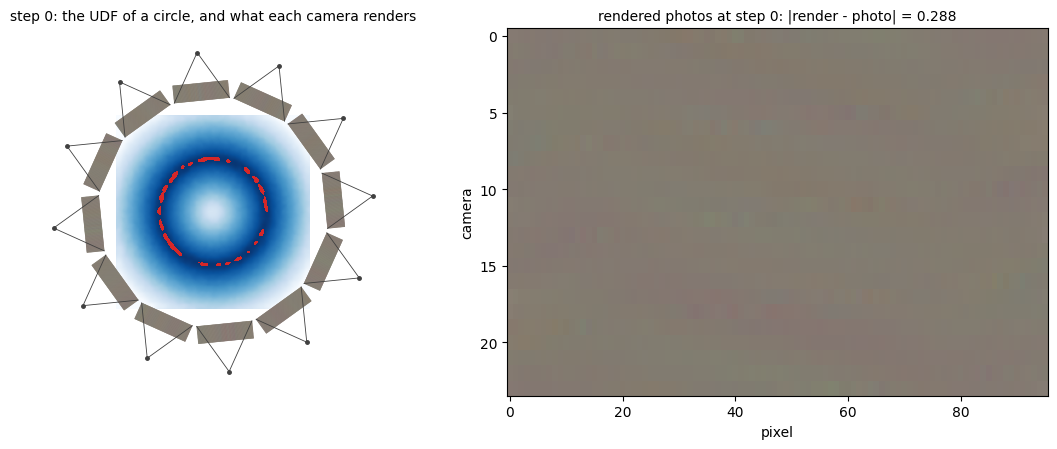

In [8]:
torch.manual_seed(SEED)
model = UDFScene()
init_circle(model)
start_renders = render_all(model.udf, model.color, 10.0, 10.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw=dict(width_ratios=[1, 1.15]))
F0 = field_image(model)
axes[0].imshow(F0, extent=(-LIM, LIM, -LIM, LIM), origin="lower", cmap="Blues_r", vmin=0, vmax=0.9)
axes[0].contourf(F0, levels=[0, 0.02], extent=(-LIM, LIM, -LIM, LIM), colors="tab:red")
draw_rig(axes[0], start_renders)
axes[0].set_title("step 0: the UDF of a circle, and what each camera renders", fontsize=10)
axes[1].imshow(start_renders, aspect="auto", interpolation="nearest")
axes[1].set_xlabel("pixel"); axes[1].set_ylabel("camera")
axes[1].set_title(f"rendered photos at step 0: |render - photo| = {np.abs(start_renders - photos).mean():.3f}", fontsize=10)
plt.tight_layout()
plt.show()

## B.4 Training: render, compare with the photos, backpropagate

One iteration is the loop of slide 42:

1. pick a batch of rays (pixels) from all cameras;
2. render them with the current $f_\theta$ and $\mathbf c_\theta$;
3. compare with the real pixels: $\lvert\hat C-C\rvert$, plus the Eikonal term
   $(\lVert\nabla f\rVert-1)^2$ on random points so that $f$ stays a distance;
4. backpropagate to **both** networks and update.

The sharpness $\kappa=\beta$ is annealed from 10 to 300 (the paper learns it). Early on,
surfaces are soft and the gradients reach far. At the end, only $f\approx 0$ counts as a surface.

In [9]:
N_ITERS = 1500 if FAST_MODE else 3000
BATCH, LAMBDA_EIK = 256, 0.3
SNAPSHOTS = [0, 150, 500, N_ITERS]

def sharpness(it):
    return 10.0 * 30.0 ** (it / N_ITERS)          # kappa = beta: 10 -> 300

torch.manual_seed(SEED)
np.random.seed(SEED)
model = UDFScene()
init_circle(model)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

snapshots, losses = {}, []
t0 = time.time()
for it in range(N_ITERS + 1):
    s = sharpness(it)
    if it in SNAPSHOTS:
        snapshots[it] = dict(field=field_image(model), renders=render_all(model.udf, model.color, s, s))
    if it == N_ITERS:
        break

    idx = torch.randint(0, len(pixels), (BATCH,))
    out = render(model.udf, model.color, rays_o[idx], rays_d[idx], s, s, jitter=True)
    colour_loss = (out["pixel"] - pixels[idx]).abs().mean()           # the only supervision

    x = ((2 * torch.rand(512, 2) - 1) * LIM).requires_grad_(True)
    grad = torch.autograd.grad(model.udf(x).sum(), x, create_graph=True)[0]
    eikonal = ((grad.norm(dim=-1) - 1) ** 2).mean()

    loss = colour_loss + LAMBDA_EIK * eikonal
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(colour_loss.item())

    if it % 250 == 0:
        print(f"iter {it:5d} | kappa = beta = {s:6.1f} | |render - photo| {colour_loss.item():.4f} "
              f"| eikonal {eikonal.item():.4f}")

print(f"training: {time.time() - t0:.1f}s for {N_ITERS} iterations")

iter     0 | kappa = beta =   10.0 | |render - photo| 0.2880 | eikonal 0.0410
iter   250 | kappa = beta =   17.6 | |render - photo| 0.0760 | eikonal 0.0340
iter   500 | kappa = beta =   31.1 | |render - photo| 0.0389 | eikonal 0.0240
iter   750 | kappa = beta =   54.8 | |render - photo| 0.0274 | eikonal 0.0206
iter  1000 | kappa = beta =   96.5 | |render - photo| 0.0170 | eikonal 0.0149
iter  1250 | kappa = beta =  170.2 | |render - photo| 0.0176 | eikonal 0.0141
training: 165.7s for 1500 iterations


## B.5 Watch the field and the photos evolve

Top: the field at each snapshot (dark means close; red: where $f<0.02$; dashed: the true curves,
which training never sees) with every other camera showing what it **renders** at that step.
Bottom: all 24 rendered photos. The last column is the target.

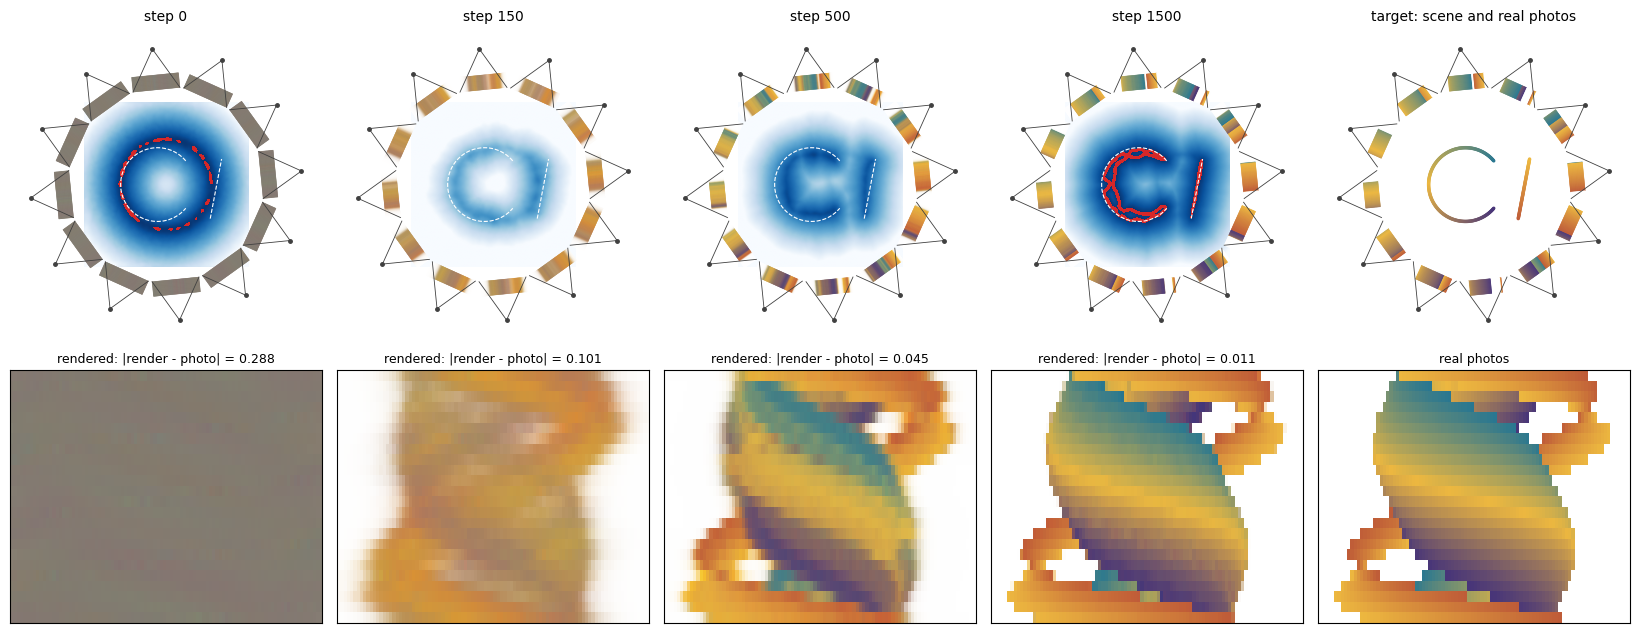

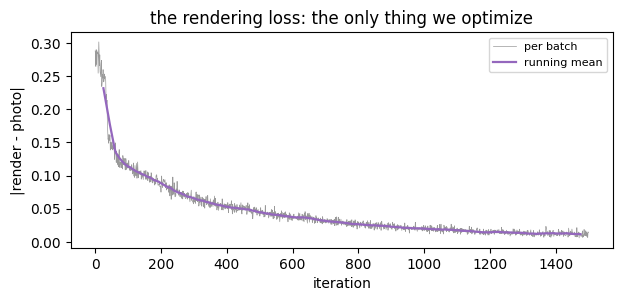

In [10]:
cols = list(snapshots.items()) + [("target", None)]
fig, axes = plt.subplots(2, len(cols), figsize=(3.3 * len(cols), 6.4),
                         gridspec_kw=dict(height_ratios=[1.35, 1]))
for j, (it, snap) in enumerate(cols):
    top, bottom = axes[0, j], axes[1, j]
    if snap is None:
        draw_scene(top); draw_rig(top, photos)
        bottom.imshow(photos, aspect="auto", interpolation="nearest")
        top.set_title("target: scene and real photos", fontsize=10)
        bottom.set_title("real photos", fontsize=9)
    else:
        F = snap["field"]
        top.imshow(F, extent=(-LIM, LIM, -LIM, LIM), origin="lower", cmap="Blues_r", vmin=0, vmax=0.9)
        top.contourf(F, levels=[0, 0.02], extent=(-LIM, LIM, -LIM, LIM), colors="tab:red")
        for pts, _ in scene:
            top.plot(*pts.T, color="white", lw=0.8, ls="--")
        draw_rig(top, snap["renders"])
        err = np.abs(snap["renders"] - photos).mean()
        top.set_title(f"step {it}", fontsize=10)
        bottom.imshow(snap["renders"], aspect="auto", interpolation="nearest")
        bottom.set_title(f"rendered: |render - photo| = {err:.3f}", fontsize=9)
    bottom.set_xticks([]); bottom.set_yticks([])
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 2.8))
plt.plot(losses, lw=0.5, color="0.6", label="per batch")
smooth = np.convolve(losses, np.ones(50) / 50, mode="valid")
plt.plot(np.arange(len(smooth)) + 25, smooth, lw=1.6, color="tab:purple", label="running mean")
plt.xlabel("iteration"); plt.ylabel("|render - photo|")
plt.title("the rendering loss: the only thing we optimize")
plt.legend(fontsize=8)
plt.show()

## B.6 A view it never saw, and the geometry it never saw

A new camera halfway between two training cameras: nobody showed the network this photo.
We also compare the learned distance with the true UDF, which training never used either.

new view:  |render - photo| = 0.007
learned f on the true curves: median 0.022  (0 would be perfect)
|f - true UDF| within 0.3 of the curves: 0.045


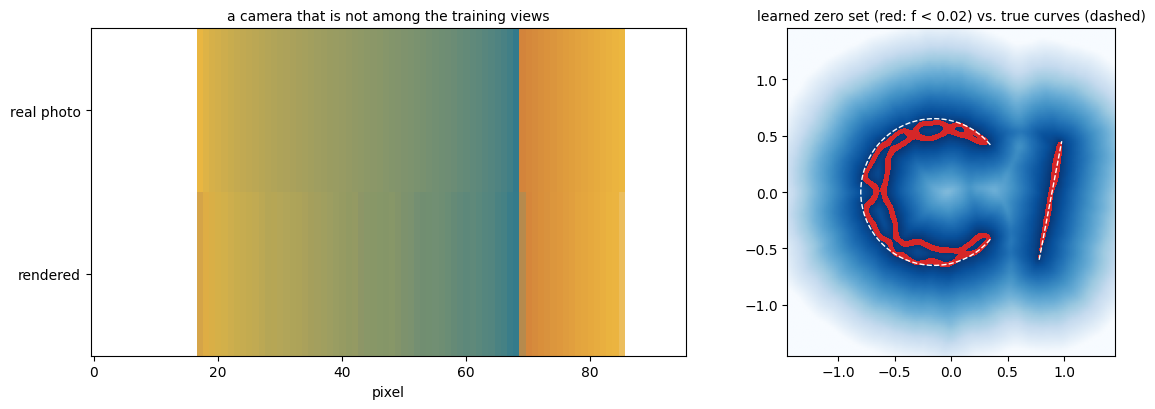

In [11]:
o_new, d_new = camera(7.5)                        # halfway between cameras 7 and 8
photo_new = take_photo(o_new, d_new)
s_end = sharpness(N_ITERS)
render_new = render_all(model.udf, model.color, s_end, s_end,
                        o=torch.tensor(o_new, dtype=torch.float32), d=torch.tensor(d_new, dtype=torch.float32))[0]

F = field_image(model).reshape(-1)
F_true = true_udf(grid_pts)
band = F_true < 0.3
with torch.no_grad():
    on_curves = model.udf(torch.tensor(truth_pts, dtype=torch.float32)).numpy()

print(f"new view:  |render - photo| = {np.abs(render_new - photo_new).mean():.3f}")
print(f"learned f on the true curves: median {np.median(on_curves):.3f}  (0 would be perfect)")
print(f"|f - true UDF| within 0.3 of the curves: {np.abs(F - F_true)[band].mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw=dict(width_ratios=[1.3, 1]))
axes[0].imshow(np.stack([photo_new, render_new]), aspect="auto", interpolation="nearest")
axes[0].set_yticks([0, 1], ["real photo", "rendered"]); axes[0].set_xlabel("pixel")
axes[0].set_title("a camera that is not among the training views", fontsize=10)
Fi = F.reshape(len(grid), len(grid))
axes[1].imshow(Fi, extent=(-LIM, LIM, -LIM, LIM), origin="lower", cmap="Blues_r", vmin=0, vmax=0.9)
axes[1].contourf(Fi, levels=[0, 0.02], extent=(-LIM, LIM, -LIM, LIM), colors="tab:red")
for pts, _ in scene:
    axes[1].plot(*pts.T, color="white", lw=1, ls="--")
axes[1].set_title("learned zero set (red: f < 0.02) vs. true curves (dashed)", fontsize=10)
axes[1].set_aspect("equal")
plt.tight_layout()
plt.show()

## B.7 Reading the result

- **The loop works.** We optimized only the rendering loss. It fell from 0.29 to about 0.015,
  and the 24 rendered photos are almost indistinguishable from the real ones (B.5).
- **It is not memorizing pixels.** The camera of B.6 was never shown to the network, yet its
  render matches the real photo to 0.007. The colours are attached to a geometry, not to the
  training rays.
- **The geometry comes from the photos alone.** The learned UDF reaches (almost) zero on the true
  curves (median 0.022). The bar is recovered almost exactly: every camera sees it, from one side
  or the other.
- **Where it is weaker, and why.** On its left the learned arc sits slightly inside the true one,
  and along the upper left the zero set is doubled by an extra inner sheet. Cameras outside the
  arc only see its outer side; its inner side is visible only through the opening, from a few
  cameras. The photos cannot tell those fields apart, so nothing removes the extra sheet. Image
  supervision constrains only what the cameras can see.
- **The order of events in B.5.** At step 150, before any shape appears, the circle has
  dissolved and the renders are a blur of roughly the right colours: with small $\kappa$ and
  $\beta$ every surface is soft, so the network fits colours first. The shape sharpens as the
  annealing leaves only $f\approx 0$ opaque. *Things to try* 2 shows what happens if it stops early.

(Numbers for `SEED = 7`. The details of the extra sheet change with the seed.)

## B.8 What this simplified version leaves out

We kept only the mechanism. The actual NeuralUDF (Long et al., CVPR 2023) adds, among other
things:

- **3D** scenes and real multi-view images (DTU, DeepFashion3D), with larger networks and much
  longer schedules;
- **hierarchical sampling** along each ray, so that samples concentrate near the surface;
- $\kappa$ and $\beta$ as **learned** parameters (annealed by hand here), and $\nabla f$ computed
  by autograd at every sample (here $df/dt$ along the ray);
- a **view-dependent** colour network $\mathbf c(\mathbf x,\mathbf v,\ldots)$ fed with features of the UDF network;
- a patch-level **SSIM** loss, an **iso-surface regularizer** that keeps the zero set thin, and
  an optional mask loss;
- mesh extraction from the learned UDF with **MeshUDF**.

Check the paper and the official repository (`xxlong0/NeuralUDF`) before quoting details.

### Things to try

1. **No indicator.** Pass `use_indicator=False` to `render` in the training loop. The front sheet
   turns translucent: what happens to the parts of the scene behind it?
2. **Soft sharpness.** Stop the annealing at 60 (`10.0 * 6.0 ** (it / N_ITERS)`). The photos are
   still matched, but look at the median of $f$ on the true curves: does the UDF reach zero?
3. **Fewer cameras.** Set `N_CAMS = 6` in B.1. With so few views, several fields explain the
   photos: which one does the network pick?
4. **No Eikonal term.** Set `LAMBDA_EIK = 0` and look at the field away from the curves.
5. **No gradient mask.** Replace `m` by `torch.ones_like(f)` in `render`. $\Psi$ now drops in
   *front* of every surface: where does the weight peak move?

> **↪ Back to the slides — slide 48:** *"Complementary volume-rendering developments"*

---

---

# LAB C — DUDF: smooth the kink, keep the zero set

> **⟵ Coming from slides 56–60** &nbsp;·&nbsp; *"Recall the UDF kink" → "If the surface gradient becomes zero, where do normals come from?"*
> **Hand-off slide:** 61 — *"Now to the notebook"*

**Why we are here.** Across the surface, a UDF behaves like $|s|$: a V whose gradient jumps
from $-1$ to $+1$. A smooth network cannot represent that corner, so it rounds it off, and
the gradient near the surface is exactly where it is least reliable. DUDF (Fainstein, Siless
& Iarussi, CVPR 2024) learns a different field instead,

$$t(\mathbf x)=d(\mathbf x)\,\tanh\big(\alpha\,d(\mathbf x)\big),\qquad
\lVert\nabla t\rVert=\phi=\tanh(\alpha d)+\alpha d\,\big(1-\tanh^2(\alpha d)\big),$$

with the same zero set, a quadratic bottom instead of a V, and $\nabla t=\mathbf 0$ on the
surface. Normals then come from the Hessian (slide 60).

We train **the same network twice** on an open 2D curve, once on the plain UDF and once on
DUDF, and run the diagnostics of slide 61: distance and gradient-norm slices, normals, and
extraction. As in LABs A and B this is a **deliberately simplified** version; C.7 lists what
the paper adds.

## C.1 The curve and the two target fields

An open curve with two free ends and two tight bends. The plain target is its distance $d$;
the DUDF target is $t=d\tanh(\alpha d)$. We use $\alpha=10$, so the smoothing is visible at the
scale of the plot. The paper uses $\alpha=100$ on its shapes.

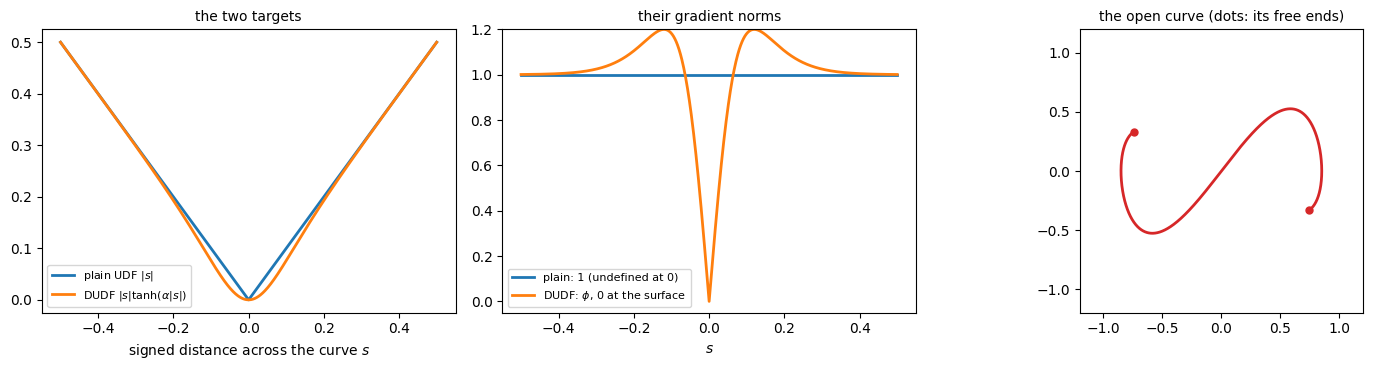

In [3]:
ALPHA = 10.0

def open_curve(u):
    return np.column_stack([0.85 * np.sin(1.6 * u), 0.55 * np.sin(3.2 * u) * np.cos(0.6 * u)])

u_curve = np.linspace(-1.3, 1.3, 6000)
curve_c = open_curve(u_curve)                                   # dense samples of the curve
tangent_c = np.gradient(curve_c, axis=0)
tangent_c /= np.linalg.norm(tangent_c, axis=1, keepdims=True)
normal_c = tangent_c @ np.array([[0, 1], [-1, 0]])              # unit normals (one side)
curve_tree = cKDTree(curve_c)
LIM_C = 1.2                                                     # domain [-LIM_C, LIM_C]^2

def dist_c(p):
    return curve_tree.query(p)[0]

def dudf_target(d):
    return d * np.tanh(ALPHA * d)

def dudf_phi(d):                                                # |grad t| as a function of d
    th = np.tanh(ALPHA * d)
    return th + ALPHA * d * (1 - th ** 2)

s = np.linspace(-0.5, 0.5, 801)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), gridspec_kw=dict(width_ratios=[1, 1, 1.25]))
axes[0].plot(s, np.abs(s), lw=2, label="plain UDF $|s|$")
axes[0].plot(s, dudf_target(np.abs(s)), lw=2, label=r"DUDF $|s|\tanh(\alpha|s|)$")
axes[0].set_xlabel("signed distance across the curve $s$"); axes[0].set_title("the two targets", fontsize=10)
axes[0].legend(fontsize=8)
axes[1].plot(s, np.ones_like(s), lw=2, label="plain: 1 (undefined at 0)")
axes[1].plot(s, dudf_phi(np.abs(s)), lw=2, label=r"DUDF: $\phi$, 0 at the surface")
axes[1].set_xlabel("$s$"); axes[1].set_ylim(-0.05, 1.2); axes[1].set_title("their gradient norms", fontsize=10)
axes[1].legend(fontsize=8)
axes[2].plot(*curve_c.T, color="tab:red", lw=2)
axes[2].plot(*curve_c[[0, -1]].T, "o", color="tab:red", ms=5)
axes[2].set_aspect("equal"); axes[2].set_xlim(-LIM_C, LIM_C); axes[2].set_ylim(-LIM_C, LIM_C)
axes[2].set_title("the open curve (dots: its free ends)", fontsize=10)
plt.tight_layout()
plt.show()

## C.2 One network, two targets

Both fields use the same SIREN (sine activations, as in DUDF), the same samples and the same
number of steps. Only the target and its conditions change:

| | plain UDF | DUDF |
|:--|:--|:--|
| value off the surface | $\lvert f-d\rvert$ | $\lvert f-t\rvert$ |
| Eikonal | $\big\lvert\lVert\nabla f\rVert-1\big\rvert$ | $\big\lvert\lVert\nabla f\rVert-\phi\big\rvert$ |
| on the surface | $\lvert f\rvert$ | $\lvert f\rvert$ (Dirichlet) and $\lVert\nabla f\rVert$ (Neumann) |

Two differences from the paper, both to keep the comparison fair. The paper's objective has
no value term $\lvert f-t\rvert$ (the Eikonal term with $\phi$ carries the distance); we give
the same value term to both fields. The paper also has a fourth term that aligns the Hessian
eigenvector with the **true** normals; we leave it out, so that **neither field is ever shown a
normal**. Whatever normals come out in C.4 are learned from distances alone.

In [4]:
class Sine(nn.Module):
    def __init__(self, n_in, n_out, w0=30.0, first=False):
        super().__init__()
        self.w0, self.lin = w0, nn.Linear(n_in, n_out)
        bound = 1 / n_in if first else math.sqrt(6 / n_in) / w0
        nn.init.uniform_(self.lin.weight, -bound, bound)

    def forward(self, x):
        return torch.sin(self.w0 * self.lin(x))

class Siren(nn.Module):
    def __init__(self, hidden=128, depth=3):
        super().__init__()
        self.body = nn.Sequential(Sine(2, hidden, first=True), *[Sine(hidden, hidden) for _ in range(depth - 1)])
        self.head = nn.Linear(hidden, 1)
        nn.init.uniform_(self.head.weight, -math.sqrt(6 / hidden) / 30, math.sqrt(6 / hidden) / 30)

    def forward(self, x):
        return self.head(self.body(x)).squeeze(-1)

def gradient(f, x, create_graph=True):
    return torch.autograd.grad(f.sum(), x, create_graph=create_graph)[0]

def hessian_normal(model, x, create_graph=True):
    # Eigenvector of the Hessian with the largest-magnitude eigenvalue, plus f and grad f.
    x = x.detach().requires_grad_(True)
    f = model(x)
    g = gradient(f, x)
    H = torch.stack([torch.autograd.grad(g[:, i].sum(), x, create_graph=create_graph, retain_graph=True)[0]
                     for i in range(2)], 1)                                         # (N, 2, 2) Hessian
    evals, evecs = torch.linalg.eigh(0.5 * (H + H.transpose(1, 2)))
    k = evals.abs().argmax(1)
    return evecs[torch.arange(len(x)), :, k], f, g

def sample_batch(n_off=2000, n_on=512):
    # Off-surface: half uniform, half close to the curve. On-surface: curve points and normals.
    x_off = np.concatenate([np.random.uniform(-LIM_C, LIM_C, (n_off // 2, 2)),
                            curve_c[np.random.randint(0, len(curve_c), n_off // 2)]
                            + np.random.normal(0, 0.05, (n_off // 2, 2))])
    idx = np.random.randint(0, len(curve_c), n_on)
    as_t = lambda a: torch.tensor(a, dtype=torch.float32)
    return as_t(x_off), as_t(dist_c(x_off)), as_t(curve_c[idx]), as_t(normal_c[idx])

N_ITERS_C = 2000 if FAST_MODE else 4000

def train_field(kind):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    model = Siren()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    t0 = time.time()
    for it in range(N_ITERS_C):
        x_off, d_off, x_on, n_on = sample_batch()
        x_off.requires_grad_(True)
        f = model(x_off)
        grad_norm = gradient(f, x_off).norm(dim=-1)
        if kind == "plain":
            target, grad_target = d_off, torch.ones_like(d_off)
        else:
            th = torch.tanh(ALPHA * d_off)
            target, grad_target = d_off * th, th + ALPHA * d_off * (1 - th ** 2)
        loss = (f - target).abs().mean() + 0.1 * (grad_norm - grad_target).abs().mean()
        x_on.requires_grad_(True)
        f_on = model(x_on)
        loss = loss + f_on.abs().mean()                                   # Dirichlet: f = 0 on the curve
        if kind == "dudf":
            loss = loss + 0.1 * gradient(f_on, x_on).norm(dim=-1).mean()   # Neumann: grad f = 0 on the curve
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if it % 500 == 0:
            print(f"{kind:5s} iter {it:5d} | loss {loss.item():.4f}")
    print(f"{kind}: {time.time() - t0:.1f}s for {N_ITERS_C} iterations")
    return model

fields = {kind: train_field(kind) for kind in ("plain", "dudf")}

plain iter     0 | loss 0.2855
plain iter   500 | loss 0.0189
plain iter  1000 | loss 0.0137
plain iter  1500 | loss 0.0121
plain: 46.9s for 2000 iterations
dudf  iter     0 | loss 0.2987
dudf  iter   500 | loss 0.0154
dudf  iter  1000 | loss 0.0102
dudf  iter  1500 | loss 0.0115
dudf: 55.3s for 2000 iterations


## C.3 Distance and gradient-norm slices

Top row: the learned fields. Bottom row: their gradient norm. The plain field should have
$\lVert\nabla f\rVert=1$ everywhere, and the DUDF field should follow $\phi$, which is 0 on the curve.
Both have thin ridges along the medial axis, where every distance field has a kink; the
difference is **on the curve**.

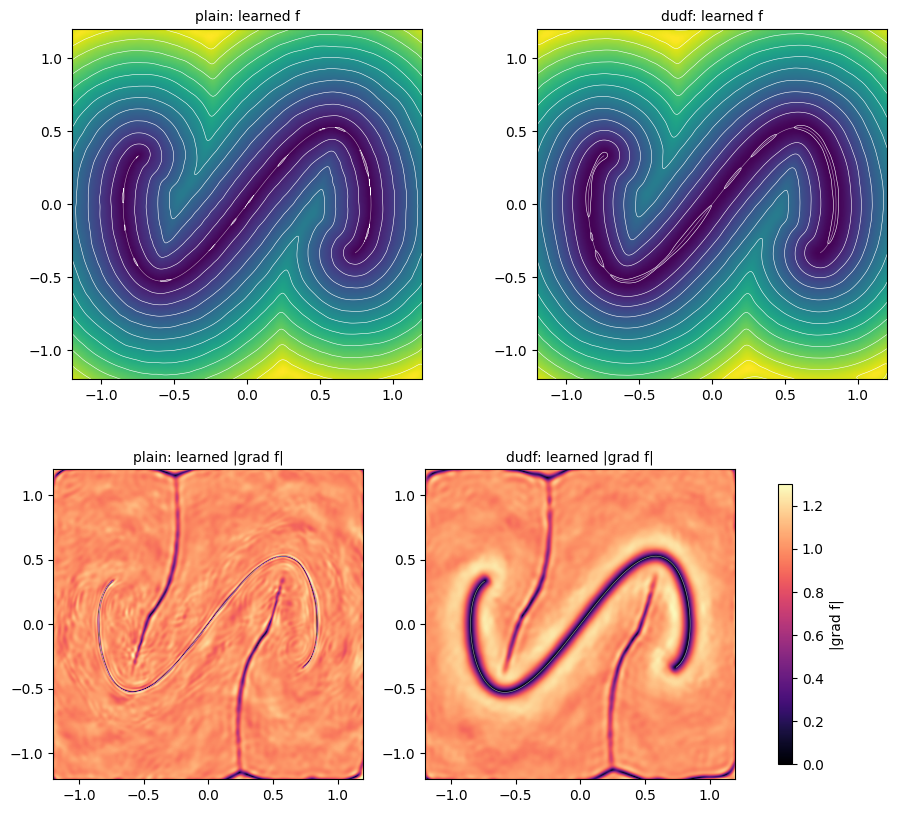

plain: |f - target| 0.0022 | |grad f| error: within 0.03 of the curve 0.174, beyond 0.1 0.044
dudf : |f - target| 0.0031 | |grad f| error: within 0.03 of the curve 0.013, beyond 0.1 0.040


In [5]:
g_c = np.linspace(-LIM_C, LIM_C, 300)
P_c = np.stack(np.meshgrid(g_c, g_c), -1).reshape(-1, 2)
D_c = dist_c(P_c)

def field_and_grad(model, pts):
    x = torch.tensor(pts, dtype=torch.float32, requires_grad=True)
    f = model(x)
    g = gradient(f, x, create_graph=False)
    return f.detach().numpy(), g.detach().numpy()

slices = {kind: field_and_grad(m, P_c) for kind, m in fields.items()}
targets = {"plain": (D_c, np.ones_like(D_c)), "dudf": (dudf_target(D_c), dudf_phi(D_c))}

fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for j, kind in enumerate(("plain", "dudf")):
    f, g = slices[kind]
    ext = (-LIM_C, LIM_C, -LIM_C, LIM_C)
    axes[0, j].imshow(f.reshape(300, 300), extent=ext, origin="lower", cmap="viridis")
    axes[0, j].contour(f.reshape(300, 300), levels=12, extent=ext, colors="white", linewidths=0.4)
    axes[0, j].set_title(f"{kind}: learned f", fontsize=10)
    im = axes[1, j].imshow(np.linalg.norm(g, axis=1).reshape(300, 300), extent=ext, origin="lower",
                           cmap="magma", vmin=0, vmax=1.3)
    axes[1, j].set_title(f"{kind}: learned |grad f|", fontsize=10)
    for ax in axes[:, j]:
        ax.plot(*curve_c.T, color="white", lw=0.4, alpha=0.6)
fig.colorbar(im, ax=axes[1], shrink=0.8, label="|grad f|")
plt.show()

near, far = D_c < 0.03, D_c > 0.1
for kind in ("plain", "dudf"):
    f, g = slices[kind]
    t, gt = targets[kind]
    gerr = np.abs(np.linalg.norm(g, axis=1) - gt)
    print(f"{kind:5s}: |f - target| {np.abs(f - t).mean():.4f} | |grad f| error: within 0.03 of the curve "
          f"{gerr[near].mean():.3f}, beyond 0.1 {gerr[far].mean():.3f}")

### One line across the curve

Cut straight across the curve at one point and plot both fields and their gradient norms
against their targets. This is slide 58, learned.

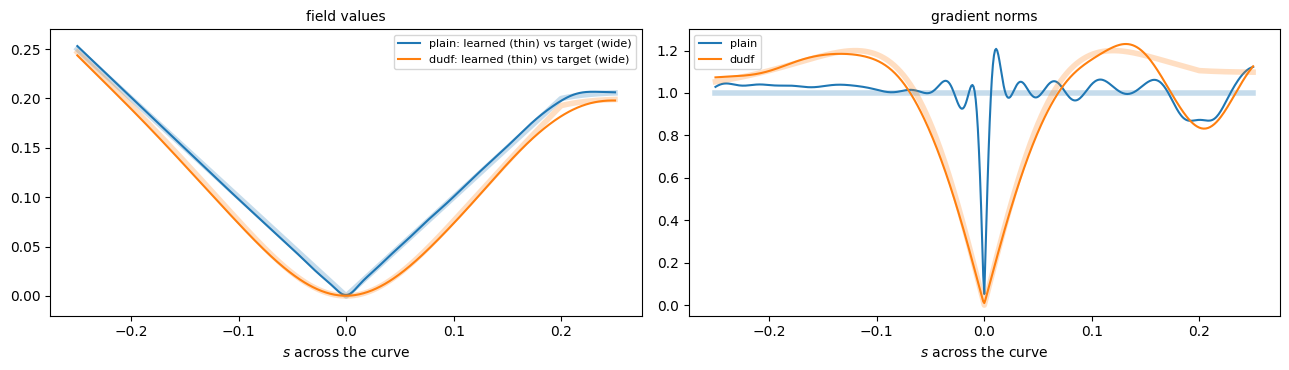

In [6]:
k0 = 1500                                                     # a point on the curve's first bend
s_line = np.linspace(-0.25, 0.25, 501)
line = curve_c[k0] + s_line[:, None] * normal_c[k0]
d_line = dist_c(line)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for kind, col in (("plain", "tab:blue"), ("dudf", "tab:orange")):
    f, g = field_and_grad(fields[kind], line)
    t, gt = (d_line, np.ones_like(d_line)) if kind == "plain" else (dudf_target(d_line), dudf_phi(d_line))
    axes[0].plot(s_line, t, color=col, lw=4, alpha=0.25)
    axes[0].plot(s_line, f, color=col, lw=1.5, label=f"{kind}: learned (thin) vs target (wide)")
    axes[1].plot(s_line, gt, color=col, lw=4, alpha=0.25)
    axes[1].plot(s_line, np.linalg.norm(g, axis=1), color=col, lw=1.5, label=kind)
axes[0].set_xlabel("$s$ across the curve"); axes[0].set_title("field values", fontsize=10)
axes[0].legend(fontsize=8); axes[0].set_ylim(-0.02, 0.27)
axes[1].set_xlabel("$s$ across the curve"); axes[1].set_title("gradient norms", fontsize=10)
axes[1].legend(fontsize=8); axes[1].set_ylim(-0.05, 1.3)
plt.tight_layout()
plt.show()

## C.4 Normals where the gradient vanishes

On the curve, the plain field's normal is its gradient direction, which is exactly where
the gradient is undefined. DUDF instead uses the Hessian eigenvector $\mathbf v_1$ with the
largest-magnitude eigenvalue (slide 60). Why it works: near the surface $t\approx\alpha s^2$,
so the Hessian is $\approx 2\alpha\,\mathbf n\mathbf n^\top$, with $\mathbf n$ as its top eigenvector.
Both estimates are unoriented, so we measure the angle to the true normal up to sign. Remember
that neither field was trained with normals.

plain: gradient           : median  14.9 deg | worse than 20 deg: 40%
DUDF: Hessian eigenvector : median   0.5 deg | worse than 20 deg: 0%


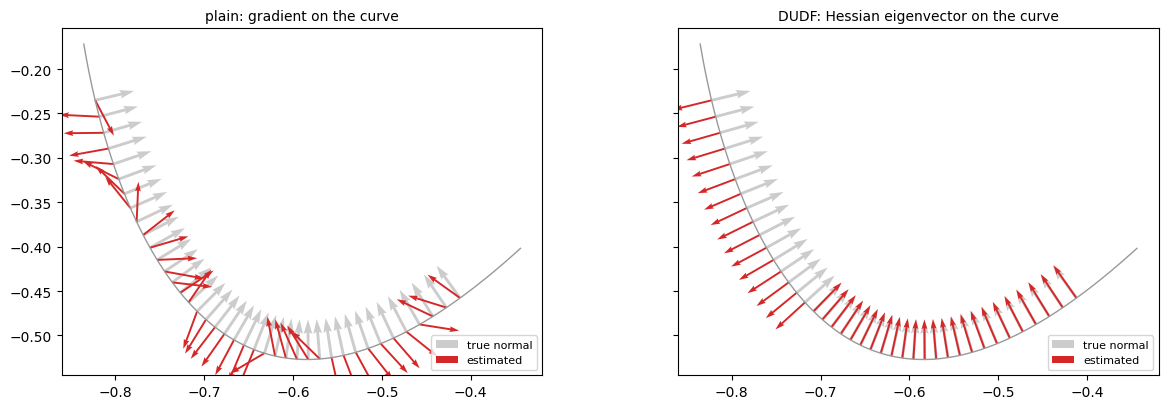

In [7]:
idx_n = np.arange(0, len(curve_c), 10)
x_n = torch.tensor(curve_c[idx_n], dtype=torch.float32)

_, g_plain = field_and_grad(fields["plain"], curve_c[idx_n])
n_plain = g_plain / np.linalg.norm(g_plain, axis=1, keepdims=True)
v1, _, _ = hessian_normal(fields["dudf"], x_n, create_graph=False)
n_dudf = v1.detach().numpy()

def angle_error(n_est):
    return np.degrees(np.arccos(np.clip(np.abs((n_est * normal_c[idx_n]).sum(1)), 0, 1)))

errors = {"plain: gradient": angle_error(n_plain), "DUDF: Hessian eigenvector": angle_error(n_dudf)}
for name, err in errors.items():
    print(f"{name:26s}: median {np.median(err):5.1f} deg | worse than 20 deg: {np.mean(err > 20):.0%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
zoom = slice(1100, 2300, 30)                                   # a stretch around the first bend
for ax, (name, n_est) in zip(axes, (("plain: gradient on the curve", n_plain),
                                     ("DUDF: Hessian eigenvector on the curve", n_dudf))):
    ax.plot(*curve_c[1000:2400].T, color="0.6", lw=1)
    sel = np.arange(len(idx_n))[(idx_n >= zoom.start) & (idx_n < zoom.stop)][::3]
    p = curve_c[idx_n[sel]]
    ax.quiver(*p.T, *normal_c[idx_n[sel]].T, color="0.8", scale=12, width=0.006, label="true normal")
    ax.quiver(*p.T, *n_est[sel].T, color="tab:red", scale=12, width=0.004, label="estimated")
    ax.set_aspect("equal"); ax.set_title(name, fontsize=10); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## C.5 Extraction: where does each field cross the curve?

The 2D version of gradient-based Marching Cubes. On an $n\times n$ grid, a grid edge crosses
the surface when both ends are close (recovered distance below a band) and **the gradient
flips direction** between them. The crossing point is placed by linear interpolation of the
recovered distances. For DUDF, the distance is recovered as in the paper: divide by $\alpha$,
then take the square root ($t\approx\alpha d^2$ near the surface).

DUDF's gradient fades to zero on the surface **by design**. So on a fine grid, the flip of
its small normal component can be drowned by small tangential errors, and the plain flip
test $\nabla f(\mathbf a)\cdot\nabla f(\mathbf b)<0$ misses crossings. The fix uses what DUDF
gives us instead of a gradient: compare only the components of $\nabla f$ along the Hessian
normal $\mathbf v_1$.

We measure **coverage** (fraction of the curve with an extracted point within 1.5 cells),
**pieces** (how many separate runs cover it), the **mean error** of the points, and the
**spurious** points more than 2 cells from the curve.

n = 300  plain + gradient flip: coverage 1.00 | pieces  1 | mean error 0.0014 | spurious 0.0%
n = 300  dudf  + gradient flip: coverage 0.98 | pieces  5 | mean error 0.0029 | spurious 0.0%
n = 300  dudf  + hessian  flip: coverage 1.00 | pieces  1 | mean error 0.0039 | spurious 2.6%
n = 600  plain + gradient flip: coverage 0.99 | pieces  2 | mean error 0.0012 | spurious 0.0%
n = 600  dudf  + gradient flip: coverage 0.84 | pieces 26 | mean error 0.0016 | spurious 0.0%
n = 600  dudf  + hessian  flip: coverage 1.00 | pieces  1 | mean error 0.0027 | spurious 3.1%


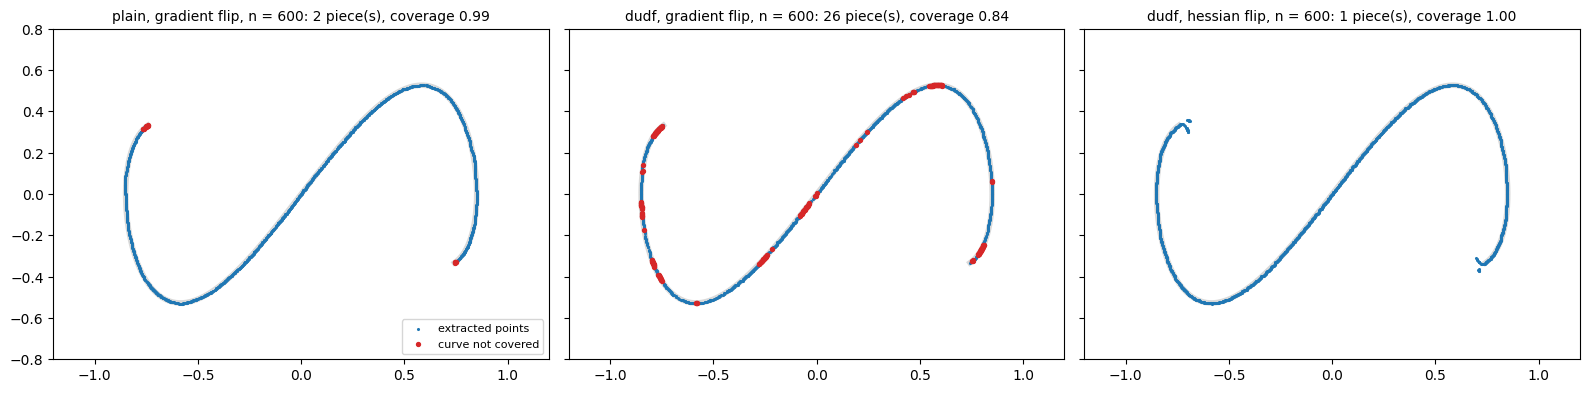

In [8]:
def grid_quantities(model, n, with_hessian=False, chunk=20000):
    gx = np.linspace(-LIM_C, LIM_C, n)
    G = np.stack(np.meshgrid(gx, gx), -1)                           # G[i, j] = (x_j, y_i)
    pts = torch.tensor(G.reshape(-1, 2), dtype=torch.float32)
    F, Gr, V = [], [], []
    for x in pts.split(chunk):
        if with_hessian:
            v1, f, g = hessian_normal(model, x, create_graph=False)
            V.append(v1.detach().numpy())
        else:
            x = x.requires_grad_(True)
            f = model(x)
            g = gradient(f, x, create_graph=False)
        F.append(f.detach().numpy()); Gr.append(g.detach().numpy())
    shape = (n, n)
    return (G, np.concatenate(F).reshape(shape), np.concatenate(Gr).reshape(*shape, 2),
            np.concatenate(V).reshape(*shape, 2) if with_hessian else None)

def extract_curve(model, kind, n, flip_rule="gradient", band=0.05):
    G, f, g, v1 = grid_quantities(model, n, with_hessian=(flip_rule == "hessian"))
    d_hat = f.clip(0) if kind == "plain" else np.sqrt(f.clip(0) / ALPHA)   # recovered distance
    points = []
    for a, b in (((slice(None), slice(0, -1)), (slice(None), slice(1, None))),     # horizontal edges
                 ((slice(0, -1), slice(None)), (slice(1, None), slice(None)))):    # vertical edges
        if flip_rule == "gradient":
            flip = (g[a] * g[b]).sum(-1) < 0
        else:                                             # compare only the normal components
            va, vb = v1[a], v1[b]
            vb = vb * np.sign((va * vb).sum(-1, keepdims=True))            # eigenvectors: sign is arbitrary
            normal = va + vb
            flip = (g[a] * normal).sum(-1) * (g[b] * normal).sum(-1) < 0
        cross = flip & (d_hat[a] < band) & (d_hat[b] < band)
        w = d_hat[a] / np.maximum(d_hat[a] + d_hat[b], 1e-9)
        points.append((G[a] + w[..., None] * (G[b] - G[a]))[cross])
    return np.concatenate(points)

def score(points, n):
    h = 2 * LIM_C / (n - 1)
    covered = cKDTree(points).query(curve_c[::5])[0] < 1.5 * h
    pieces = (np.diff(np.r_[0, covered.astype(int), 0]) == 1).sum()
    err = dist_c(points)
    return dict(coverage=covered.mean(), pieces=pieces, error=err.mean(), spurious=(err > 2 * h).mean(),
                covered=covered)

runs = [("plain", "gradient"), ("dudf", "gradient"), ("dudf", "hessian")]
results = {}
for n in (300, 600):
    for kind, rule in runs:
        pts = extract_curve(fields[kind], kind, n, rule)
        results[(kind, rule, n)] = (pts, score(pts, n))
        r = results[(kind, rule, n)][1]
        print(f"n = {n}  {kind:5s} + {rule:8s} flip: coverage {r['coverage']:.2f} | pieces {r['pieces']:2d} "
              f"| mean error {r['error']:.4f} | spurious {r['spurious']:.1%}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=True)
for ax, (kind, rule) in zip(axes, runs):
    pts, r = results[(kind, rule, 600)]
    missed = curve_c[::5][~r["covered"]]
    ax.plot(*curve_c.T, color="0.85", lw=4, zorder=1)
    ax.scatter(*pts.T, s=1.5, color="tab:blue", zorder=2, label="extracted points")
    ax.scatter(*missed.T, s=8, color="tab:red", zorder=3, label="curve not covered")
    ax.set_aspect("equal"); ax.set_xlim(-LIM_C, LIM_C); ax.set_ylim(-0.8, 0.8)
    ax.set_title(f"{kind}, {rule} flip, n = 600: {r['pieces']} piece(s), coverage {r['coverage']:.2f}", fontsize=10)
axes[0].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

RESULTS_C_PLACEHOLDER

## C.7 What this simplified version leaves out

We kept only the mechanism. The actual DUDF (Fainstein, Siless & Iarussi, CVPR 2024) adds,
among other things:

- **3D** shapes (garments, scenes) with an 8-layer, 256-unit SIREN and $\alpha=100$;
- no value term: the distance enters only through the heterogeneous Eikonal term with $\phi$,
  with large weights on the Eikonal, Dirichlet and Neumann terms;
- a **maximum-curvature term** that aligns the Hessian eigenvector with ground-truth normals;
- a **refinement phase** that pushes the mean and spread of $f$ on the surface to zero;
- **gradient-based Marching Cubes** for meshing, sphere tracing for rendering, and curvatures
  computed from the Hessian;
- distance recovery for downstream use, and orientation of the normals from the camera
  position.

Check the paper and the official repository (`LIA-DiTella/DiffUDF`) before quoting details.

### Things to try

1. **Change $\alpha$.** Try `ALPHA = 3` and `ALPHA = 30` in C.1. How wide is the dark band of
   $\lVert\nabla f\rVert$, and what happens to the normals?
2. **The paper's normal term.** Add `0.01 * (1 - (v1 * n_on).sum(-1).abs()).mean()` to the DUDF
   loss, with `v1, _, _ = hessian_normal(model, x_on)`. It needs the true normals `n_on`: how
   much does it improve on normals learned from distances alone?
3. **A smaller network.** Set `hidden=64` in `Siren`. Which field suffers more near the curve?
4. **Normals from the plain field, slightly off the curve.** Evaluate the plain gradient at
   `curve_c + 0.02 * normal_c` instead of on the curve. How far from the curve do you have to go
   before it becomes reliable?

> **↪ Back to the slides — slide 62:** *"UODF asks a different question: can distance carry structured direction?"*

---